**MOST RECENT VERSION OF THIS FILE, CHECK GITHUB FOR PROGRESS!!**

## Necessary Packages:

In [1]:
import symlib

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

import numpy as np
from numpy import polyfit

import os

import scipy
from scipy import stats
from scipy.optimize import curve_fit
from scipy.stats import linregress

from astropy.cosmology import FlatLambdaCDM

# <a id = "table_of_contents"></a>
# Table of Contents:
(click on each link to jump to the respective section)

(for this table of contents to work, run all **Markdown** cells once)

* [Mass Accretion Histories](#mass_accretion_histories)
* [Subhalo Mass Functions](#subhalo_mass_functions)
* [Nsubs(z) & Mhost(z) vs. Redshift](#nsubs_mhost_vs_redshift)
* [Nsubs(z)/Nsubs(z=0) vs. Mhost(z)/Mhost(z=0)](#norm_nsubs_vs_norm_host_mass)
* [Smooth vs. Clumpy Particle Accretion](#smooth_vs_clumpy_accretion)
* [Correlation Functions](#correlation_functions)
* [Subhalo Animations](#animations)

## Global variables:
*These globals are used by every function below --> this cell MUST be run before anything else*

In [4]:
## GLOBALS:
base_dir = "C:/Users/steph/Symphony"                           ## base directory, points to the container folder where the Symphony data files are

## list of suites to be analyzed
#suite_list = ["SymphonyLMC"]
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
#suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "MWest", "EDEN_MilkyWay_8K", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]

## colors for confidence band, individual hosts, etc
colors = {"SymphonyLMC": "tab:purple",
          "SymphonyMilkyWay": "tab:blue",
          "MWest": "black",
          "EDEN_MilkyWay_8K": "#5098f2",
          "SymphonyGroup": "tab:green",
          "SymphonyLCluster": "tab:orange",
          "SymphonyCluster": "tab:red"}

## colors for mean lines
avg_colors = {"SymphonyLMC": (102/225, 0/255, 110/255),
              "SymphonyMilkyWay": (7/255, 0/255, 110/255),
              "MWest": (0, 0, 0),
              "EDEN_MilkyWay_8K": (37/255, 107/255, 194/255),
              "SymphonyGroup": (22/255, 112/255, 0/255),
              "SymphonyLCluster": (163/255, 90/255, 2/255),
              "SymphonyCluster": (128/255, 3/255, 3/255)}

labels = {"SymphonyLMC": "SymphonyLMC",
          "SymphonyMilkyWay": "SymphonyMilkyWay",
          "MWest": "MWest",
          "EDEN_MilkyWay_8K": "EDEN_MilkyWay_8K",
          "SymphonyGroup": "SymphonyGroup",
          "SymphonyLCluster": "SymphonyLCluster",
          "SymphonyCluster": "SymphonyCluster"}

## suite-to-model mapping
mah_fit_model = {"SymphonyLMC": "wechsler",
                 "SymphonyMilkyWay": "wechsler",
                 "MWest": "wechsler",
                 "EDEN_MilkyWay_8K": "wechsler",
                 "SymphonyGroup": "wechsler",
                 "SymphonyLCluster": "mcbride",
                 "SymphonyCluster": "mcbride"}

## maximum x-axis extents for SHMFs
x_max_shmf = {"SymphonyLMC": 2e11,
              "SymphonyMilkyWay": 2e12,
              "MWest": 2e12,
              "EDEN_MilkyWay_8K": 2e12,
              "SymphonyGroup": 2e13,
              "SymphonyLCluster": 2e14,
              "SymphonyCluster": 2e15}

min_particles: int = 300    ## minimum number of particles for a halo to be considered "well-resolved"
z_max: float = 16.0         ## maximum redshift to keep (inclusive)

## MAH parameters:
redshift_ticks = [16, 8, 4, 2, 1, 0.5, 0.25]                   ## ticks and labels for when x_axis = "redshift"
redshift_labels = ["16", "8", "4", "2", "1", "0.5", "0.25"]
z_xlim = (16.0, 0.05)
mah_host_lw = 0.5                       ## per-host linewidth
mah_host_alpha = 0.15                   ## host alpha (opacity)
mah_avg_lw = 1.25                       ## average linewidth
mah_confidence_band_alpha = 0.25        ## alpha (opacity) of the 16-84% confidence band

## SHMF parameters:
redshifts_shmf: list[float] = [2.0, 1.0, 0.5, 0.25, 0.1, 0.0]
#redshifts_shmf: list[float] = [2.0, 1.0, 0.0]
n_bins: int = 50                                               ## number of mass bins
m_max: float = 1e15                                            ## mass of the highest mass bin
shmf_host_lw = 0.5                                             ## same as for MAHs, just for SHMFs
shmf_host_alpha = 0.15
shmf_avg_lw = 1.25
shmf_confidence_band_alpha = 0.25
shmf_ratio_min = 1e-5   ## lower x limit (Msub/Mhost)
shmf_ratio_max = 1.0    ## upper x limit (Msub/Mhost)

<a id = "mass_accretion_histories"></a>
## Mass Accretion Histories
[Back to Table of Contents](#table_of_contents)

* A "mass accretion history" is the mass of the subhalo as a function of time (snapshot, scale factor, redshift, cosmic time, etc).
* Below we focus on HOST mass accretion histories
* A 300 particle cut and a "survival cut" are applied, to exclude any times where the host was not well-resolved or well-formed
* Functionality is separated into several helper functions, a "dataloader" which loads all the relevant data in once, and then some "statistics" functions and a "plotter" function.

In [ ]:
## MAHs dataloader --> reading in data for creating MAHs for all suites in Symphony
## inputs: base_dir, suite_list

## output will be a dictionary, with indexable (key, value) pairs
## the dataloader function will be built on a per-suite basis for simplicity


## HELPER FUNCTIONS:

## build_z_mask returns a numpy array of timesteps we want to keep
def build_z_mask(scale_factors: np.ndarray, suite: str):
    
    redshifts = (1.0 / scale_factors) - 1.0
    mask = redshifts <= z_max
    if suite == "MWest":
        ## MWest behavior is different for some reason?
        mask &= scale_factors <= 1.0
        
    return mask

## due to the masking, lists may be different sizes
## so we need to pad the shorter arrays with NaN until they all match the length of the longest one
## nan_padding returns a numpy array of left-padded so that all are the same length as the longest array,
## then stacks them into a 2D array with shape (n_arrays, length)
## left-padding aligns all the arrays at their z = 0 snapshot
def nan_padding(arrays: list[np.ndarray], length: int):
    
    padded = [np.concatenate([np.full(length - len(a), np.nan), a]) for a in arrays]
    
    return np.vstack(padded)


## per-suite dataloader; loads mass accretion history information for every host in a given suite
## inputs: base_dir (string), suite (string),
##         min_mass_resolution_limit (int, usually 300 particles), z_max (float, this is somewhat arbitrarily chosen),
##         verbose (bool, controls whether progress print statements are on or off)
## outputs dict with keys:
##         scale_factors        # np.ndarray, shape (T,)   – reference time axis
##         redshifts            # np.ndarray, shape (T,)
##         masses               # np.ndarray, shape (N, T)  – NaN where unresolved
##         host_scale_factors   # list[np.ndarray]       – per-host, unpadded
##         host_masses          # list[np.ndarray]       – per-host, unpadded
##         particle_mass        # float  – mp [M_sun/h] from first host
##         n_hosts              # int
##         suite                # str

def load_MAH_suite_data(base_dir: str, suite: str, min_particles: int = min_particles, z_max: float = z_max, verbose: bool = True):
    
    n_hosts = symlib.n_hosts(suite)                 ## get the # of hosts (individual simulations in each folder)

    ## initializing empty lists to be filled later
    host_masses: list[np.ndarray] = []
    host_scale_factors: list[np.ndarray] = []
    particle_mass = None

    ## tracking any hosts that failed to load
    skipped_hosts: list[int] = []

    ## looping over hosts in a particular suite
    for i_host in range(n_hosts):
        if verbose:
            print(f"Loading host {i_host + 1} in suite {suite}", end = "\r", flush = True)

        try:
            sim_dir = symlib.get_host_directory(base_dir, suite, i_host)                ## getting the full directory to the host data
            h, hist = symlib.read_subhalos(sim_dir)                                     ## reading in the Symfind halo finder data

            ## storing particle mass for the first host (identical across a suite)
            if particle_mass is None:
                params = symlib.simulation_parameters(sim_dir)                          ## getting simulation parameters used in this suite
                particle_mass = float(params["mp"])                                     ## getting "macro-particle" mass used in this suite

            scale_factors = symlib.scale_factors(sim_dir)                               ## reading in per-host scale factors (resolves problems with masking)
            z_mask = build_z_mask(scale_factors, suite)
            scale_factors = scale_factors[z_mask]                                       ## applying the redshift cut

            ## getting host properties (host is always index 0)
            host_mass = np.array(h["mvir"][0])                                          ## host virial mass for all snapshots
            host_ok = np.array(h["ok"][0])                                              ## all snapshots where the host was properly identified by Symfind
            mass_cut = min_particles * particle_mass                                    ## 300 particles mass resolution limit

            ## applying the 300 particle resolution cut and the "ok" survival cut:
            ## keeping only snapshots where the host is "ok" AND "well-resolved" (at or above 300 particles)
            ## host_mass_masked *removes* these subhalos by replacing them with NaN
            host_mass_masked = np.where((host_mass < mass_cut) | ~host_ok, np.nan, host_mass)[z_mask]
            host_masses.append(host_mass_masked)
            host_scale_factors.append(scale_factors)

        except Exception as e:
            skipped_hosts.append(i_host)

            if verbose:
                print(f"\nSkipped host {i_host} in suite {suite}: {type(e).__name__}: {e}")

            continue

    if verbose:
        print()

        if skipped_hosts:
            print(f"Skipped {len(skipped_hosts)} corrupted host(s) in {suite}: {skipped_hosts}")

    ## use the host with the most snapshots as the reference time axis:
    ref_idx = int(np.argmax([len(s) for s in host_scale_factors]))
    ref_scale = host_scale_factors[ref_idx]
    max_len = len(ref_scale)
    masses_2D = nan_padding(host_masses, max_len)
    ref_redshift = (1.0 / ref_scale) - 1.0

    return {"suite": suite,
            "n_hosts": len(host_masses),              ## changing n_hosts to reflect only successfully loaded hosts
            "particle_mass": particle_mass,
            "scale_factors": ref_scale,               ## shape (T, )
            "redshifts": ref_redshift,                ## shape (T, )
            "masses": masses_2D,                      ## shape (N, T)
            "host_scale_factors": host_scale_factors, ## shape (N, T)
            "host_masses": host_masses,
            "skipped_hosts": skipped_hosts}


## function to automatically load all suites in suite_list, using load_MAH_suite_data:
def load_all_MAH_data(base_dir: str, suites = list[str], min_particles: int = min_particles, z_max: float = z_max, verbose: bool = True):
    
    if suites is None:
        suites = suite_list   ## defaults to the global string
    all_MAH_data: dict[str, dict] = {}
    
    for index, suite in enumerate(suites):
        all_MAH_data[suite] = load_MAH_suite_data(base_dir, suite, min_particles = min_particles, z_max = z_max, verbose = verbose)
        
    return all_MAH_data

## entrypoint to load the data
MAH_data = load_all_MAH_data(base_dir, suite_list)

Loading host 39 in suite SymphonyLMC
Loading host 45 in suite SymphonyMilkyWay
Loading host 42 in suite SymphonyGroup

The data collected by the dataloader is then passed into the "Statistics" and "Plotting" functions:

C:\Users\steph\AppData\Local\Temp\ipykernel_13156\3286572629.py:16: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(masses, axis = 0)              # (T,)
C:\Users\steph\AppData\Local\Temp\ipykernel_13156\3286572629.py:17: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(masses, axis = 0)          # (T,)


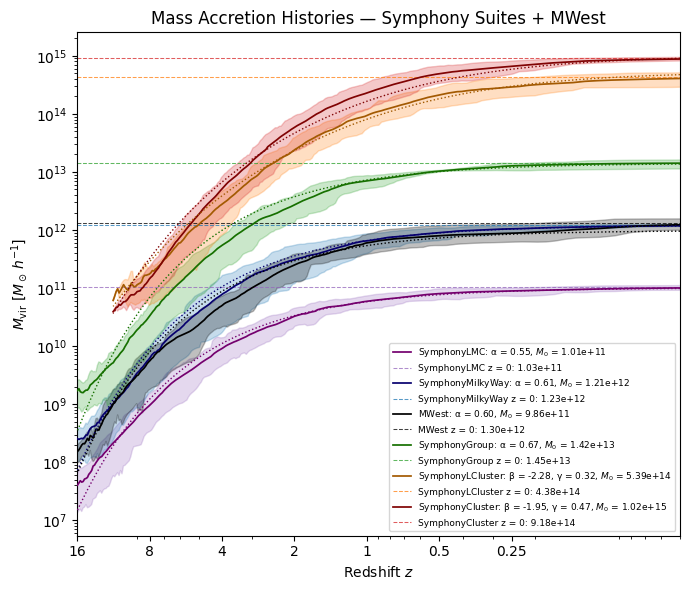

In [22]:
## STATISTICS + PLOTTER:

## STATISTICS: computes mean, median, standard deviation and 16-84% confidence band
def compute_MAH_stats(suite_data: dict):

    masses = suite_data["masses"]                    # (N, T)
    scale_factors = suite_data["scale_factors"]      # (T,)
    redshifts = suite_data["redshifts"]              # (T,)
    particle_mass = suite_data["particle_mass"]

    ## check that at least one host is well resolved at a particular timestep:
    n_resolved = np.sum(~np.isnan(masses), axis = 0) # (T,)         ## ~np.isnan gives all where the value is NOT NaN
    valid_mask = n_resolved > 0                      # (T,) bool

    ## using nan-sensitive functions
    mean = np.nanmean(masses, axis = 0)              # (T,)
    median = np.nanmedian(masses, axis = 0)          # (T,)
    std = np.nanstd(masses, axis = 0)                # (T,)
    p16 = np.nanpercentile(masses, 16, axis = 0)     # (T,)
    p84 = np.nanpercentile(masses, 84, axis = 0)     # (T,)

    # use the last snapshot where at least one host is resolved,
    # rather than blindly taking index [-1] which may be all-NaN.
    valid_indices = np.where(valid_mask)[0]
    final_mass = float(mean[valid_indices[-1]]) if len(valid_indices) > 0 else np.nan

    return {"suite": suite_data["suite"],
            "scale_factors": scale_factors,
            "redshifts": redshifts,
            "mean": mean,
            "median": median,
            "std": std,
            "p16": p16,
            "p84": p84,
            "final_mass": final_mass,
            "valid_mask": valid_mask,
            "n_resolved": n_resolved,
            "particle_mass": particle_mass}

## function to run the statistics over all suites
def compute_all_MAH_stats(all_MAH_data: dict[str, dict]):
    
    all_MAH_stats = {suite: compute_MAH_stats(suite_data) for suite, suite_data in all_MAH_data.items()}
    
    return all_MAH_stats

#####################################################################################################################

## FITTING:

## simple exponential MAH model: M(z) = M0*exp(-alpha*z) [Wechsler+ 2002 form] 
def mah_wechsler_model(z, M0, alpha):
    
    return M0*np.exp(-alpha*z)

## power-law correction
def mah_mcbride_model(z, M0, beta, gamma):
    return M0 * (1 + z)**beta * np.exp(-gamma * z)

## fit M(z) = M0*exp(-alpha*z) to the MEAN MAH of the suite
## returns dict with keys:
## M0: fitted z = 0 mass
## alpha: fitted formation rate parameter
## x_fit: x-values for plotting the fit curve
## y_fit: y-values for plotting the fit curve
## popt: raw [M0, alpha]
## pcov: covariance matrix
def fit_mah_wechsler(suite_stats, x_axis):

    valid = suite_stats["valid_mask"]
    x = suite_stats["redshifts"][valid]     ## always fit in redshift space, regardless of what the toggle is set to
    y = suite_stats["mean"][valid]

    std = suite_stats["std"][valid]
    mass_cut = min_particles * suite_stats["particle_mass"]

    ## fit only where the mean is above 300 particles resolution limit and finite
    ## initial guess: M0 = final mass, alpha = 0.5
    ## fit in log-mass space
    fit_mask = (y > mass_cut) & np.isfinite(y) & (std > 0)
    x_fit_data = x[fit_mask]
    y_fit_data = y[fit_mask]

    log_y = np.log(y_fit_data)
    log_sigma = std[fit_mask] / y_fit_data          ## σ_log(M) ≈ σ_M / M
    p0 = [np.log(suite_stats["final_mass"]), 0.5]
    popt, pcov = curve_fit(lambda z, logM0, alpha: logM0 - alpha * z,
                           x_fit_data, log_y, sigma = log_sigma, absolute_sigma = True,
                           p0 = p0, maxfev = 10000)
    
    logM0, alpha = popt
    M0 = np.exp(logM0)

    ## generate smooth curve for plotting
    ## spans the full x-axis range
    x_smooth = np.linspace(0, suite_stats["redshifts"][suite_stats["valid_mask"]].max(), 500)
    y_smooth = mah_wechsler_model(x_smooth, M0, alpha)

    ## convert x_smooth to scale factor if required by toggle
    x_plot = x_smooth if x_axis == "redshift" else (1.0/(x_smooth + 1.0))

    return {"M0": M0,
            "alpha": alpha,
            "x_fit": x_plot,
            "y_fit": y_smooth,
            "popt": popt,
            "pcov": pcov}

def fit_mah_mcbride(suite_stats, x_axis):

    valid = suite_stats["valid_mask"]
    x = suite_stats["redshifts"][valid]
    y = suite_stats["mean"][valid]
    
    std = suite_stats["std"][valid]
    mass_cut = min_particles * suite_stats["particle_mass"]

    ## same as in the wechsler fit
    fit_mask = (y > mass_cut) & np.isfinite(y) & (std > 0)
    x_fit_data = x[fit_mask]
    y_fit_data = y[fit_mask]

    ## fit in log-space: log(M) = log(M0) + beta*log(1+z) - gamma*z
    log_y = np.log(y_fit_data)
    log_sigma = std[fit_mask] / y_fit_data                ## σ_log(M) ≈ σ_M / M
    p0 = [np.log(suite_stats["final_mass"]), 0.5, 0.5]
    popt, pcov = curve_fit(lambda z, logM0, beta, gamma: logM0 + beta * np.log(1 + z) - gamma * z,
                           x_fit_data, log_y, sigma = log_sigma, absolute_sigma = True,
                           p0 = p0, maxfev = 10000)
    
    logM0, beta, gamma = popt
    M0 = np.exp(logM0)

    ## x_smooth spans the full x-axis range
    x_smooth = np.linspace(0, suite_stats["redshifts"][suite_stats["valid_mask"]].max(), 500)
    y_smooth = mah_mcbride_model(x_smooth, M0, beta, gamma)
    x_plot = x_smooth if x_axis == "redshift" else (1.0 / (x_smooth + 1.0))

    return {"M0": M0,
            "beta": beta,
            "gamma": gamma,
            "x_fit": x_plot,
            "y_fit": y_smooth,
            "popt": popt,
            "pcov": pcov}


def fit_all_mah_wechsler(all_MAH_stats, x_axis):
    return {suite: fit_mah_wechsler(suite_stats, x_axis = x_axis) for suite, suite_stats in all_MAH_stats.items()}

def fit_all_mah_mcbride(all_MAH_stats, x_axis):
    return {suite: fit_mah_mcbride(suite_stats, x_axis = x_axis) for suite, suite_stats in all_MAH_stats.items()}


def fit_mah_suite(suite_stats, suite, x_axis):
    model = mah_fit_model.get(suite, "wechsler")   ## default to wechsler if suite not in dict
    if model == "wechsler":
        return fit_mah_wechsler(suite_stats, x_axis)
    elif model == "mcbride":
        return fit_mah_mcbride(suite_stats, x_axis)

def fit_all_mah(all_MAH_stats, x_axis):
    return {suite: fit_mah_suite(suite_stats, suite, x_axis) for suite, suite_stats in all_MAH_stats.items()}

#####################################################################################################################

## MAIN PLOTTER:

## plotting helpers:

## getting the correct x-axis
def get_xaxis(suite_stats: dict, x_axis: str):
    
    if x_axis == "scale_factor":
        return suite_stats["scale_factors"]
    elif x_axis == "redshift":
        return suite_stats["redshifts"]
    else:
        raise ValueError(f"x_axis must be 'scale_factor' or 'redshift', but got {x_axis!r}")

## configuring axes
def ax_config_MAH(ax: matplotlib.axes.Axes, x_axis: str):
    
    ax.set_yscale("log")
    ax.set_ylabel(r"$M_\mathrm{vir}\ [M_\odot\,h^{-1}]$", fontsize = 10)

    if x_axis == "scale_factor":
        ax.set_xlabel("Scale Factor $a$", fontsize = 10)

    elif x_axis == "redshift":
        ax.set_xscale("log")
        ax.set_xticks(redshift_ticks)
        ax.set_xticklabels(redshift_labels)
        ax.set_xlim(z_xlim)
        ax.set_xlabel(r"Redshift $z$", fontsize = 10)

## plotting per-suite data:
def plot_suite_MAH(ax: matplotlib.axes.Axes, suite: str, suite_data: dict, suite_stats: dict, x_axis: str,
                   show_hosts: bool = True, show_confidence: bool = True, show_fit = False, mah_fits = None):

    color = colors[suite]
    avg_color = avg_colors[suite]
    valid = suite_stats["valid_mask"]
    x = get_xaxis(suite_stats, x_axis)
    mass_cut = min_particles * suite_stats["particle_mass"]

    ## individual hosts --> split solid-dashed line at 300 particle masses
    if show_hosts:
        for host_sf, host_mass in zip(suite_data["host_scale_factors"], suite_data["host_masses"]):

            ## each host has its own time axis:
            host_x = host_sf if x_axis == "scale_factor" else ((1.0 / host_sf) - 1.0)

            ## resolved if above the mass cut:
            resolved = host_mass >= mass_cut

            ## solid where resolved:
            ax.plot(np.where(resolved, host_x, np.nan), np.where(resolved, host_mass, np.nan),
                    color = color, lw = mah_host_lw, alpha = mah_host_alpha)

            ## dashed where unresolved:
            ax.plot(np.where(~resolved, host_x, np.nan), np.where(~resolved, host_mass, np.nan),
                    color = color, lw = mah_host_lw, alpha = mah_host_alpha, linestyle = "--")

    ## 16-84% confidence band:
    if show_confidence:
        ax.fill_between(x[valid], suite_stats["p16"][valid], suite_stats["p84"][valid], color = color, alpha = mah_confidence_band_alpha)

    ## mean --> split solid/dashed at 300 particles
    mean = suite_stats["mean"]
    resolved_mean = (mean >= mass_cut) & valid
    unresolved_mean = (mean < mass_cut) & valid

    ## solid for resolved
    ax.plot(np.where(resolved_mean, x, np.nan), np.where(resolved_mean, mean, np.nan),
            color = avg_color, lw = mah_avg_lw, zorder = 3, label = suite)

    ## dashed for unresolved
    ax.plot(np.where(unresolved_mean, x, np.nan), np.where(unresolved_mean, mean, np.nan),
            color = avg_color, lw = mah_avg_lw, zorder = 3, linestyle = "--")

    ## exponential fit:
    if show_fit and mah_fits is not None and suite in mah_fits:
        fits = mah_fits[suite]
        ax.plot(fits["x_fit"], fits["y_fit"], color = avg_colors[suite], lw = 1.0, linestyle = ":", zorder = 4)

    ## final mass line:
    fm = suite_stats["final_mass"]
    if np.isfinite(fm):
        ax.axhline(fm, color = colors[suite], linestyle = "--", lw = 0.75, alpha = 0.75, label = f"z = 0 mass: {fm:.2e}")


## adding the option to normalize by the z = 0 mass accretion history:

## computing z = 0 normalized masses:
def compute_normalized_masses(suite_data: dict):
    
    masses = suite_data["masses"].copy()
    z0_masses = masses[:, -1]
    norm_masses = masses / z0_masses[:, np.newaxis]

    return norm_masses

def plot_suite_MAH_normalized(ax: matplotlib.axes.Axes, suite: str, suite_data: dict, suite_stats: dict, x_axis: str,
                              show_hosts: bool, show_confidence: bool = True):

    color = colors[suite]
    avg_color = avg_colors[suite]
    valid = suite_stats["valid_mask"]
    x = get_xaxis(suite_stats, x_axis)
    fm = suite_stats["final_mass"]

    norm_masses = compute_normalized_masses(suite_data)
    norm_mean = np.nanmean(norm_masses, axis = 0)
    norm_p16 = np.nanpercentile(norm_masses, 16, axis = 0)
    norm_p84 = np.nanpercentile(norm_masses, 84, axis = 0)

    ## individual hosts normalized by their own z=0 mass:
    if show_hosts:
        for host_sf, host_mass in zip(suite_data["host_scale_factors"], suite_data["host_masses"]):
            host_x  = host_sf if x_axis == "scale_factor" else ((1.0 / host_sf) - 1.0)
            host_fm = host_mass[-1]
            if np.isfinite(host_fm) and host_fm != 0:
                ax.plot(host_x, host_mass / host_fm, color = color, lw = mah_host_lw, alpha = mah_host_alpha)

    if show_confidence:
        ax.fill_between(x[valid], norm_p16[valid], norm_p84[valid], color = color, alpha = mah_confidence_band_alpha)
    ax.plot(x[valid], norm_mean[valid], color = avg_color, lw = mah_avg_lw, zorder = 3, label = suite)

## putting it all together:
## all_MAH_data = data dictionary from load_all_MAH_data
## all_MAH_stats = data dictionary from compute_all_MAH_stats
## outputs a single-panel figure (or double-panel if "dual" = True)

def plot_all_MAH(all_MAH_data: dict[str, dict], all_MAH_stats: dict[str, dict], suites: list[str],
                 x_axis: str = "scale_factor", show_hosts: bool = True, dual: bool = False,
                 show_confidence: bool = False, show_fit = False,
                 figsize_single: tuple[float, float] = (7, 6), figsize_dual: tuple[float, float] = (14, 6),
                 title: str = "Mass Accretion Histories — Symphony Suites + MWest"):

    if suites is None:
        suites = [s for s in suite_list if s in all_MAH_data]

    figsize = figsize_dual if dual else figsize_single
    ncols = 2 if dual else 1
    
    fig, axes = plt.subplots(ncols = ncols, figsize = figsize)
    
    ax_main = axes[1] if dual else axes
    ax_norm = axes[0] if dual else None

    ## compute fits if needed
    mah_fits = fit_all_mah(all_MAH_stats, x_axis = x_axis) if show_fit else None

    for suite in suites:
        plot_suite_MAH(ax_main, suite, all_MAH_data[suite], all_MAH_stats[suite], x_axis = x_axis, show_hosts = show_hosts,
                       show_confidence = show_confidence, show_fit = show_fit, mah_fits = mah_fits)

        if dual:
            plot_suite_MAH_normalized(ax_norm, suite, all_MAH_data[suite], all_MAH_stats[suite], x_axis = x_axis,
                                      show_hosts = show_hosts, show_confidence = show_confidence)

    ax_config_MAH(ax_main, x_axis)
    
    if dual:
        ax_config_MAH(ax_norm, x_axis)
        #ax_norm.set_yscale("linear")
        ax_norm.set_ylabel(r"$M_\mathrm{vir}\ /\ M_\mathrm{vir}(z{=}0)$", fontsize = 10)

    legend_handles = []
    for s in suites:
        if show_fit and mah_fits is not None and s in mah_fits:
            fit = mah_fits[s]
            if mah_fit_model.get(s, "wechsler") == "wechsler":
                alpha_str = f": α = {fit['alpha']:.2f}, $M_0$ = {fit['M0']:.2e}"
            else:
                alpha_str = f": β = {fit['beta']:.2f}, γ = {fit['gamma']:.2f}, $M_0$ = {fit['M0']:.2e}"
        else:
            alpha_str = ""
        legend_handles.append(Line2D([0], [0], color = avg_colors[s], lw = mah_avg_lw, label = f"{s}{alpha_str}"))
        if np.isfinite(all_MAH_stats[s]["final_mass"]):
            legend_handles.append(Line2D([0], [0], color = colors[s], lw = 0.75, alpha = 0.75, linestyle = "--",
                                         label = f"{s} z = 0: {all_MAH_stats[s]['final_mass']:.2e}"))
            
    ax_main.legend(handles = legend_handles, loc = "best", fontsize = 6.5)
    ax_main.set_title(title, fontsize = 12)

    if dual:
        ## normalized panel only needs suite name labels, no final mass lines
        norm_handles = [Line2D([0], [0], color = avg_colors[s], lw = mah_avg_lw, label = s) for s in suites]
        ax_norm.legend(handles = norm_handles, loc = "best", fontsize = 8)
        ax_norm.set_title(f"{title} — Normalized", fontsize = 12)

    
    fig.tight_layout()

    return fig, axes

#####################################################################################################################

## entrypoint to generate stats & plots
MAH_stats = compute_all_MAH_stats(MAH_data)
fig, axes = plot_all_MAH(MAH_data, MAH_stats, suite_list, x_axis = "redshift", show_hosts = False, dual = False,
                         show_confidence = True, show_fit = True)

#fig.savefig(f"coefficient of variation weighted fits, all MAHs", dpi = 250, bbox_inches = "tight")
plt.show()

<a id = "subhalo_mass_functions"></a>
## Subhalo Mass Functions:
[Back to Table of Contents](#table_of_contents)

* "Subhalo mass functions" are histograms of # of subhalos separated by mass.
* 300 particle cut and "ok" survival cut also apply here, but only as a threshold for transitioning the line from solid to dashed
* Host is NOT included; this focuses on SUBHALOS
* Two kinds: differential and cumulative
* Differential --> slope expected to be ~ -1.9 to -2.0
* Cumulative --> slope expected to be ~ -0.9 to -1.0

In [9]:
## HELPERS + DATALOADER:

## returns the snapshot closest to a given redshift
def snap_at_redshift(sim_dir, target_z):
    
    scale = symlib.scale_factors(sim_dir)
    a_target = 1.0 / (1.0 + target_z)
    
    return int(np.argmin(np.abs(scale - a_target)))

## bins in Msub/Mhost ratio space (for suite ordering)
def host_shmf_ratio(sim_dir, snap, bins):

    h, hist = symlib.read_subhalos(sim_dir)
    host = h[0, snap]
    r_host = host["rvir"]
    m_host = host["mvir"]

    sub_x = h[:, snap]["x"]
    r = np.sqrt(np.sum(sub_x**2, axis = 1))

    ok = (h["ok"][:, snap] & (r < r_host))
    ok[0] = False
    m_sub = h["mvir"][:, snap][ok]

    m_ratio = m_sub/m_host

    n, _ = np.histogram(m_ratio, bins = bins)

    ## cumulative: N(> M)
    n_cumul = np.cumsum(n[::-1])[::-1].astype(float)

    ## differential: dN/d(log M)
    log_bins = np.log10(bins)
    d_log_m = np.diff(log_bins)
    n_diff = (n / d_log_m).astype(float)

    return n_cumul, n_diff, m_host


## bins in absolute Msub space (for redshift ordering)
def host_shmf_abs(sim_dir, snap, bins):
    
    h, hist = symlib.read_subhalos(sim_dir)
    host = h[0, snap]
    r_host = host["rvir"]
    m_host = host["mvir"]
    
    sub_x = h[:, snap]["x"]
    r = np.sqrt(np.sum(sub_x**2, axis = 1))

    ok = (h["ok"][:, snap] & (r < r_host))
    ok[0] = False
    m_sub = h["mvir"][:, snap][ok]
    n, _ = np.histogram(m_sub, bins = bins)
    n_cumul = np.cumsum(n[::-1])[::-1].astype(float)
    log_bins = np.log10(bins)
    d_log_m = np.diff(log_bins)
    n_diff = (n / d_log_m).astype(float)
    return n_cumul, n_diff, m_host
    
#######################################################################################################################

## DATALOADER (ratio space)
def load_suite_shmf_ratio(suite, target_z):
    
    n_hosts = symlib.n_hosts(suite)
    print(f"[ratio] {suite} at z = {target_z} ({n_hosts} hosts)...")

    snap = None            ## will be set from the first host
    bin_centers = None
    bins = np.logspace(np.log10(shmf_ratio_min), np.log10(shmf_ratio_max), n_bins + 1)
    bin_centers = np.sqrt(bins[:-1] * bins[1:])
    
    all_ncumul = []        ## one row per host
    all_ndiff = []
    conv_masses = []
    host_masses = []
    failed_hosts = []

    for i_host in range(n_hosts):
        print(f"Host {i_host + 1}/{n_hosts}", end = "\r")

        sim_dir = symlib.get_host_directory(base_dir, suite, i_host)

        try:
            if snap is None:
                snap = snap_at_redshift(sim_dir, target_z)

            ## getting particle mass
            params = symlib.simulation_parameters(sim_dir)
            mp = params["mp"] / params["h100"]

            n_cumul, n_diff, m_host = host_shmf_ratio(sim_dir, snap, bins)

            ## skip hosts with no subhalos at this snapshot:
            if np.all(n_cumul == 0):
                print(f"\nWarning: host {i_host} has no subhalos at z = {target_z}, skipping.")
                continue
        
            all_ncumul.append(n_cumul)
            all_ndiff.append(n_diff)
            conv_masses.append(min_particles * mp / m_host)    ## ratio-space convergence limit
            host_masses.append(m_host)

        except Exception as e:
            print(f"\nWarning: host {i_host} failed to load ({type(e).__name__}: {e}), skipping.")
            failed_hosts.append(i_host)
            continue

    print()   ## newline after \r
    print(f"Loaded {len(all_ncumul)}/{n_hosts} hosts.")
    if failed_hosts:
        print(f"Failed hosts: {failed_hosts}")

    return bin_centers, np.array(all_ncumul), np.array(all_ndiff), np.array(conv_masses), np.array(host_masses)


## DATALOADER (absolute mass space)

def load_suite_shmf_abs(suite, target_z):

    n_hosts = symlib.n_hosts(suite)
    print(f"[abs] {suite} at z = {target_z} ({n_hosts} hosts)...")

    snap = None
    bins = None
    bin_centers = None
    all_ncumul = []
    all_ndiff = []
    conv_masses = []
    host_masses = []
    failed_hosts = []

    for i_host in range(n_hosts):
        print(f"Host {i_host + 1}/{n_hosts}", end="\r")

        sim_dir = symlib.get_host_directory(base_dir, suite, i_host)

        try:
            if snap is None:
                snap = snap_at_redshift(sim_dir, target_z)
            params = symlib.simulation_parameters(sim_dir)
            mp = params["mp"] / params["h100"]
            if bins is None:
                m_min_suite = min_particles * mp * 0.1
                bins = np.logspace(np.log10(m_min_suite), np.log10(m_max), n_bins + 1)
                bin_centers = np.sqrt(bins[:-1] * bins[1:])
            n_cumul, n_diff, m_host = host_shmf_abs(sim_dir, snap, bins)

            if np.all(n_cumul == 0):
                print(f"\nWarning: host {i_host} has no subhalos at z = {target_z}, skipping.")
                continue

            all_ncumul.append(n_cumul)
            all_ndiff.append(n_diff)
            conv_masses.append(min_particles * mp)  ## absolute convergence limit
            host_masses.append(m_host)

        except Exception as e:
            print(f"\nWarning: host {i_host} failed ({type(e).__name__}: {e}), skipping.")
            failed_hosts.append(i_host)

    print()
    print(f"Loaded {len(all_ncumul)}/{n_hosts} hosts.")
    if failed_hosts:
        print(f"Failed hosts: {failed_hosts}")
    
    return bin_centers, np.array(all_ncumul), np.array(all_ndiff), np.array(conv_masses), np.array(host_masses)

The cell below just loops the dataloaders over all the suites and caches all the data into dictionaries:

In [10]:
cached_data_ratio = {}  ## Msub/Mhost --> used for suite panels
cached_data_abs   = {}  ## absolute Msub --> used for redshift panels

print("Caching ratio-space data...")
for target_z in redshifts_shmf:
    for suite in suite_list:
        cached_data_ratio[(suite, target_z)] = load_suite_shmf_ratio(suite, target_z)

print("\nCaching absolute-mass data...")
for target_z in redshifts_shmf:
    for suite in suite_list:
        cached_data_abs[(suite, target_z)] = load_suite_shmf_abs(suite, target_z)

print("\nAll data cached.")

Caching ratio-space data...
[ratio] SymphonyLMC at z = 2.0 (39 hosts)...
Host 39/39
Loaded 39/39 hosts.
[ratio] SymphonyMilkyWay at z = 2.0 (45 hosts)...
Host 45/45
Loaded 45/45 hosts.
[ratio] MWest at z = 2.0 (20 hosts)...
Host 20/20
Loaded 20/20 hosts.
[ratio] SymphonyGroup at z = 2.0 (49 hosts)...
Host 49/49
Loaded 49/49 hosts.
[ratio] SymphonyLCluster at z = 2.0 (33 hosts)...
Host 33/33
Loaded 33/33 hosts.
[ratio] SymphonyCluster at z = 2.0 (81 hosts)...
Host 81/81
Loaded 81/81 hosts.
[ratio] SymphonyLMC at z = 1.0 (39 hosts)...
Host 39/39
Loaded 39/39 hosts.
[ratio] SymphonyMilkyWay at z = 1.0 (45 hosts)...
Host 45/45
Loaded 45/45 hosts.
[ratio] MWest at z = 1.0 (20 hosts)...
Host 20/20
Loaded 20/20 hosts.
[ratio] SymphonyGroup at z = 1.0 (49 hosts)...
Host 49/49
Loaded 49/49 hosts.
[ratio] SymphonyLCluster at z = 1.0 (33 hosts)...
Host 33/33
Loaded 33/33 hosts.
[ratio] SymphonyCluster at z = 1.0 (81 hosts)...
Host 81/81
Loaded 81/81 hosts.
[ratio] SymphonyLMC at z = 0.5 (39 hosts

In [11]:
## STATISTICS
## computes summary statistics from the per-host SHMF array
## returns:
## mean_ncumul: mean cumulative SHMF across hosts, shape (n_bins,)
## p16, p84: 16th and 84th percentiles of host-to-host scatter
## median_conv_mass: median convergence limit in M_sun across hosts
def compute_shmf_stats(all_n, conv_masses):
    
    mean_n = np.mean(all_n, axis = 0)
    p16 = np.percentile(all_n, 16, axis = 0)
    p84 = np.percentile(all_n, 84, axis = 0)
    median_conv_mass = np.median(conv_masses)

    print(f"Convergence limit: {median_conv_mass:.3e}")

    return mean_n, p16, p84, median_conv_mass

## fits a power law (linear in log-log space) to y
## lower bound is the mass bin corresponding to the 300 particles "convergence limit"
## upper bound is the mass bin corresponding closest to where the mean SHMF crosses over 10^-1
def fit_powerlaw(bin_centers, y, solid_mask, p16, p84, y_floor = 1e-1):
    
    fit_mask = solid_mask & (y > y_floor)

    if np.sum(fit_mask) < 2:
        print("Warning: fewer than 2 bins in fit range, skipping fit.")
        return None

    log_x = np.log10(bin_centers[fit_mask])
    log_y = np.log10(y[fit_mask])

    ## weights: inverse variance in log space from 16-84% band
    log_p16 = np.log10(p16.clip(min = 0.01)[fit_mask])
    log_p84 = np.log10(p84.clip(min = 0.01)[fit_mask])
    log_sigma = (log_p84 - log_p16) / 2.0
    log_sigma = np.where(log_sigma > 0, log_sigma, np.min(log_sigma[log_sigma > 0]))  ## avoid zero weights
    weights = 1.0 / log_sigma**2

    slope, intercept = np.polyfit(log_x, log_y, 1, w = weights)

    ## weighted R²
    log_y_pred = slope * log_x + intercept
    log_y_mean = np.average(log_y, weights = weights)
    ss_res = np.sum(weights * (log_y - log_y_pred)**2)
    ss_tot = np.sum(weights * (log_y - log_y_mean)**2)
    r2 = 1 - ss_res / ss_tot

    return slope, intercept, r2

## mixes in increasing amounts of red into the colors based on the redshift of the line being plotted
## objective is to visually represent the transition from high to low redshift
## MWest and Cluster are special cases, since MWest is black and Cluster is already red
## for those cases:
## MWest transitions from gray at high redshifts to black at low redshifts
## Cluster transitions from deep red at high redshifts to normal red at low redshifts
def redshift_color(suite, target_z, max_red_mix = 0.25):
    z_max = max(redshifts_shmf) if len(redshifts_shmf) > 1 else 1.0
    t = target_z / z_max        ## 0 at z=0, 1 at z = z_max

    base = np.array(mcolors.to_rgb(avg_colors[suite]))

    if suite == "MWest":
        ## black at z = 0, light gray at z = z_max
        gray = np.array([0.65, 0.65, 0.65])
        return tuple((1 - t) * base + t * gray)

    elif suite == "SymphonyCluster":
        ## lighter red at z = 0, darker red at z = z_max
        dark_red = np.array([0.45, 0.0, 0.0])
        return tuple((1 - t) * base + t * dark_red)

    else:
        ## all other suites: blend toward red with increasing redshift
        red = np.array([1.0, 0.0, 0.0])
        return tuple((1 - t) * base + t * (red * max_red_mix + base * (1 - max_red_mix)))
    
#######################################################################################################################

## CORE PLOTTER:
## plots the SHMF line for one suite and one redshift on the given axes
## affected by the show_host_shmf and show_confidence_shmf toggles
## line_color and line_label are passed in by the panel function
def plot_shmf_line(ax, suite, target_z, line_color, line_label, use_ratio = True):

    cache = cached_data_ratio if use_ratio else cached_data_abs

    ## unpacking the dictionary created in the previous step
    bin_centers, all_ncumul, all_ndiff, conv_masses, host_masses = cache[(suite, target_z)]
    #median_host_mass = np.median(host_masses)
    n_hosts = all_ncumul.shape[0]

    ## choose differential or cumulative:
    if show_differential:
        mean_n, p16, p84, median_conv_mass = compute_shmf_stats(all_ndiff, conv_masses)
        ylabel = r"$dN_{\rm sub}/d\log M_{\rm sub}$"
        all_n = all_ndiff

    else:
        mean_n, p16, p84, median_conv_mass = compute_shmf_stats(all_ncumul, conv_masses)
        ylabel = r"$N_{\rm sub}(> M_{\rm sub})$"
        all_n = all_ncumul

    ## solid-dashed split at the bin where x = median_conv_mass (min_particles * mp)
    split_idx = np.searchsorted(bin_centers, median_conv_mass)
    solid_mask = np.arange(len(bin_centers)) >= split_idx
    dashed_mask = ~solid_mask

    x0 = median_conv_mass
    y0 = np.interp(x0, bin_centers, mean_n)

    p16_0 = np.interp(x0, bin_centers, p16)
    p84_0 = np.interp(x0, bin_centers, p84)
    p16_plot = p16.clip(min = 0.01)
    p84_plot = p84

    ## plot per-host lines:
    if show_hosts_shmf:
        for i in range(n_hosts):
            ax.plot(bin_centers[solid_mask], all_n[i][solid_mask], color = line_color, lw = shmf_host_lw, alpha = shmf_host_alpha)

            if show_dashed:
                ax.plot(bin_centers[dashed_mask], all_n[i][dashed_mask], color = line_color,
                        lw = shmf_host_lw, alpha = shmf_host_alpha, linestyle = "--")

    ## plot mean line:
    ax.plot(np.r_[x0, bin_centers[solid_mask]], np.r_[y0, mean_n[solid_mask]], color = line_color, lw = shmf_avg_lw, label = line_label)
    if show_dashed:
        ax.plot(np.r_[bin_centers[dashed_mask], x0], np.r_[mean_n[dashed_mask], y0], color = line_color, lw = shmf_avg_lw, linestyle = "--")

    ## plot 16-84% confidence band
    if show_confidence_shmf:
        ax.fill_between(np.r_[x0, bin_centers[solid_mask]],
                        np.r_[p16_0, p16_plot[solid_mask]],
                        np.r_[p84_0, p84_plot[solid_mask]],
                        color = line_color, alpha = shmf_confidence_band_alpha)
        if show_dashed:
            ax.fill_between(np.r_[bin_centers[dashed_mask], x0],
                            np.r_[p16_plot[dashed_mask], p16_0],
                            np.r_[p84_plot[dashed_mask], p84_0],
                            color = line_color, alpha = shmf_confidence_band_alpha)

    ## vertical line at convergence limit:
    if convergence:
        ax.axvline(median_conv_mass, color = line_color, lw = 0.75, linestyle = ":")

    ## linear fit:
    slope_out = None
    r2_out = None
    if show_shmf_fit:
        result = fit_powerlaw(bin_centers, mean_n, solid_mask, p16, p84)
        if result is not None:
            slope, intercept, r2 = result
            slope_out = slope
            r2_out = r2
            x_plot = bin_centers[solid_mask & (mean_n > 0)]
            y_plot = 10**(intercept + slope * np.log10(x_plot))
            ax.plot(x_plot, y_plot, color = line_color, lw = 1.5, linestyle = ":")
            print(f"{labels[suite]} z = {target_z}: slope = {slope:.3f}, intercept = {intercept:.3f}, R² = {r2:.4f}")

    return ylabel, slope_out, r2_out

## apply axes formatting and legend, shared by both the "suite" and "redshift" panel ordering modes
def finalize_panel(ax, ylabel, key_list, slope_dict, r2_dict, use_ratio = True):

    ax.set_xscale("log")
    ax.set_yscale("log")

    if use_ratio:
        ax.set_xlabel(r"$M_{\rm sub}/M_{\rm host}$", fontsize = 16)
        ax.set_xlim(shmf_ratio_min, shmf_ratio_max)

    else:
        ax.set_xlabel(r"$M_{\rm sub}\ [M_\odot]$", fontsize = 16)
        ax.set_xlim(1e6, max(x_max_shmf[s] for s in suite_list))
    ax.set_ylabel(ylabel, fontsize = 16)
    ax.set_ylim(1e-1, 1e4)

    handles, leg_labels = ax.get_legend_handles_labels()
    new_labels = []
    for lbl, key in zip(leg_labels, key_list):
        r2 = r2_dict.get(key, None)
        slope = slope_dict.get(key, None)
        if r2 is not None:
            new_labels.append(f"{lbl} (R² = {r2:.3f}, slope = {slope:.3f})")
        else:
            new_labels.append(lbl)
    ax.legend(handles, new_labels, fontsize = 11, framealpha = 0.75)
    

## PANEL MODE: one panel per redshift, one line per suite
def plot_redshift_panel(ax, target_z):
    
    print(f"\nPlotting panel for z = {target_z}...")
    
    ylabel = None
    slope_dict = {}
    r2_dict = {}

    for suite in suite_list:
        line_color = avg_colors[suite]
        line_label = labels[suite]
        ylabel, slope, r2 = plot_shmf_line(ax, suite, target_z, line_color, line_label, use_ratio = False)
        slope_dict[suite] = slope
        r2_dict[suite] = r2

    ax.set_title(f"z = {target_z}", fontsize = 15)
    finalize_panel(ax, ylabel, suite_list, slope_dict, r2_dict, use_ratio = False)

    print(f"Panel for z = {target_z} complete.")

## PANEL MODE: one panel per suite, one line per redshift
def plot_suite_panel(ax, suite):
    
    print(f"\nPlotting panel for {suite}...")
    
    ylabel = None
    slope_dict = {}
    r2_dict = {}

    for target_z in redshifts_shmf:
        line_color = redshift_color(suite, target_z)
        line_label = f"z = {target_z}"
        ylabel, slope, r2 = plot_shmf_line(ax, suite, target_z, line_color, line_label, use_ratio = True)
        slope_dict[target_z] = slope
        r2_dict[target_z] = r2

    ax.set_title(labels[suite], fontsize = 15)
    finalize_panel(ax, ylabel, redshifts_shmf, slope_dict, r2_dict, use_ratio = True)
    
    print(f"Panel for {suite} complete.")

The cell below adjusts all the SHMF toggles and runs the plotter:

Starting SHMF plot — panel_by = 'redshift'
Suites: ['SymphonyLMC', 'SymphonyMilkyWay', 'MWest', 'SymphonyGroup', 'SymphonyLCluster', 'SymphonyCluster']
Redshifts: [2.0, 1.0, 0.5, 0.25, 0.1, 0.0]
Toggles — host lines: False, confidence band: False, linear fit: True, differential: False, convergence: False


Plotting panel for z = 2.0...
Convergence limit: 1.511e+07
SymphonyLMC z = 2.0: slope = -0.865, intercept = 7.796, R² = 0.9972
Convergence limit: 1.208e+08
SymphonyMilkyWay z = 2.0: slope = -0.925, intercept = 9.126, R² = 0.9950
Convergence limit: 1.208e+08
MWest z = 2.0: slope = -0.836, intercept = 8.380, R² = 0.9983
Convergence limit: 9.668e+08
SymphonyGroup z = 2.0: slope = -0.963, intercept = 10.416, R² = 0.9929
Convergence limit: 6.490e+10
SymphonyLCluster z = 2.0: slope = -0.922, intercept = 11.054, R² = 0.9974
Convergence limit: 5.409e+10
SymphonyCluster z = 2.0: slope = -0.926, intercept = 11.478, R² = 0.9918
Panel for z = 2.0 complete.

Plotting panel for z = 1.0...
Converge

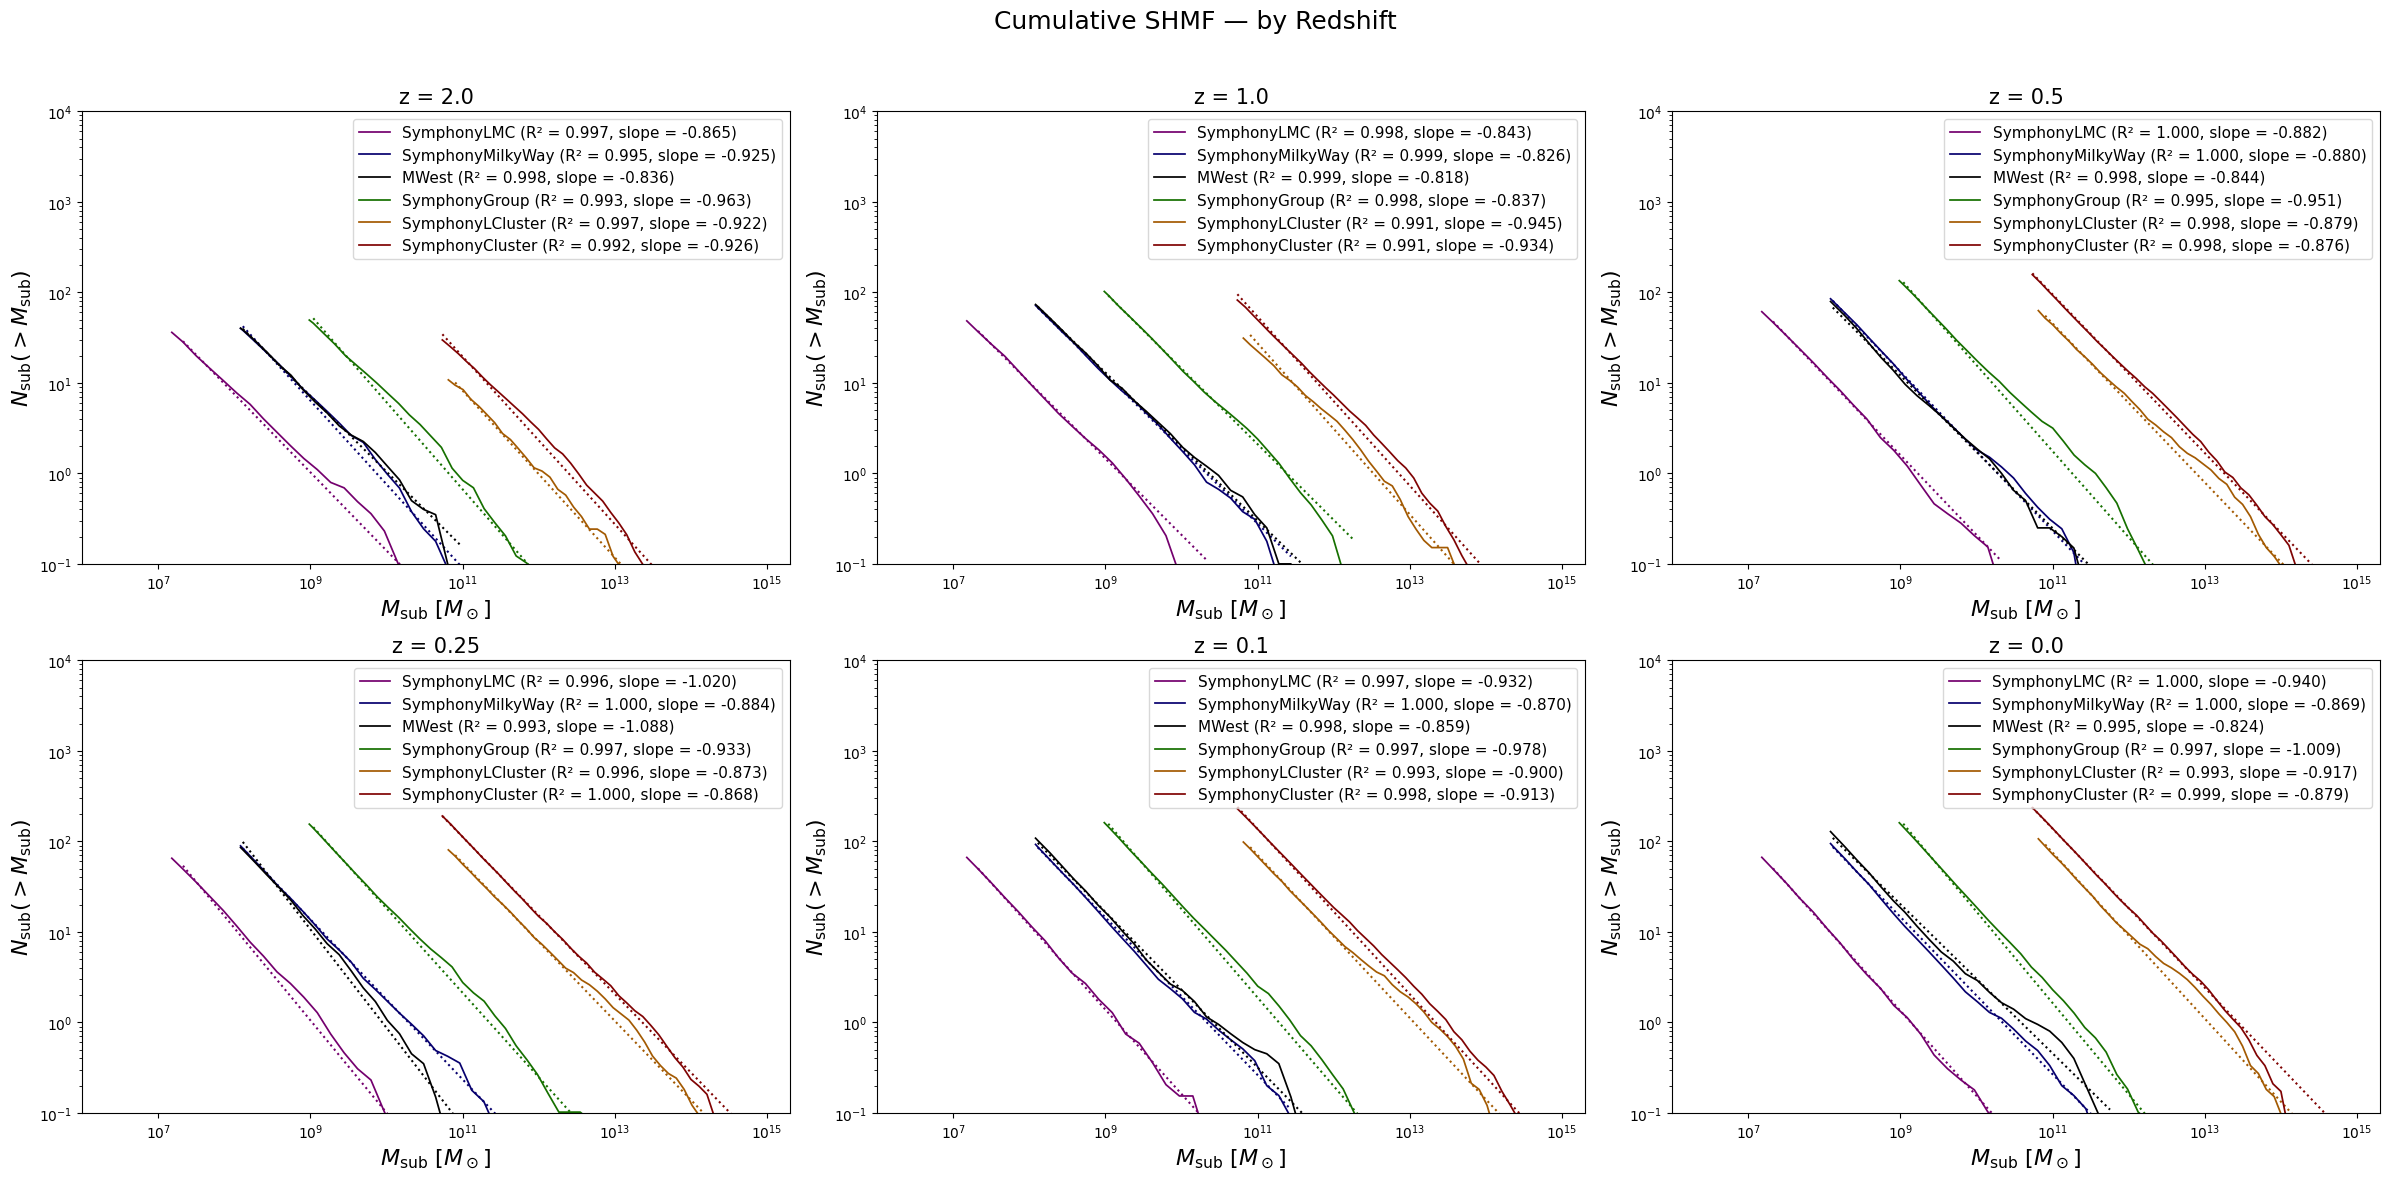

In [12]:
#TOGGLES:

## plot individual per-host lines
show_hosts_shmf = False

## plot 16-84% host-to-host scatter band
show_confidence_shmf = False

## plot linear fit to mean SHMF. True = on
## two points used for the linear fit:
## 1. bin corresponding to 300 particles
## 2. bin corresponding to where the mean SHMF crosses the 10^-1 point on the y-axis
show_shmf_fit = True

## if True, plot dN/d(log Msub) (differential SHMF)
## if False, plot N(>M) (cumulative SHMF)
show_differential = False

## if True, show the vertical line at 300 * mp (convergence)
convergence = False

## if True, the SHMF below 300 * mp is shown
show_dashed = False

## "suite" or "redshift" panel ordering
panel_by = "redshift"


## ENTRYPOINT:
if panel_by == "suite":
    panel_list = suite_list
    panel_fn = plot_suite_panel
    title_type = "by Suite"
else:
    panel_list = redshifts_shmf
    panel_fn = plot_redshift_panel
    title_type = "by Redshift"

print(f"Starting SHMF plot — panel_by = '{panel_by}'")
print(f"Suites: {suite_list}")
print(f"Redshifts: {redshifts_shmf}")
print(f"Toggles — host lines: {show_hosts_shmf}, confidence band: {show_confidence_shmf}, "
      f"linear fit: {show_shmf_fit}, differential: {show_differential}, convergence: {convergence}\n")

n_panels = len(panel_list)
max_cols = 3                                 ## maximum # of panels per row
n_cols = min(n_panels, max_cols)
n_rows = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize = (8 * n_cols, 6 * n_rows), squeeze = False)

## hide any unused axes in the last row
for idx in range(n_panels, n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

for p_idx, panel in enumerate(panel_list):
    ax = axes[p_idx // n_cols, p_idx % n_cols]
    panel_fn(ax, panel)

shmf_type = "Differential" if show_differential else "Cumulative"
fig.suptitle(f"{shmf_type} SHMF — {title_type}", fontsize = 18, y = 0.98)
plt.tight_layout(rect = [0, 0, 1, 0.96])
fig.savefig(f"SHMF weighted fits (ordered by {panel_by}).png", dpi = 150, bbox_inches = "tight")
plt.show()

<a id = "nsubs_mhost_vs_redshift"></a>
## N_subs(z) & Mhost(z) vs. Redshift
[Back to Table of Contents](#table_of_contents)

* Looking at how the host mass accretion tracks with the # of subhalos as a function of "time" (redshift)

Loading suite SymphonyLMC... (39 hosts)
Host 39/39
Loaded 39/39 hosts (0 skipped)
RMSE_mass = 0.815530%, χ^2_mass = 0.323401
RMSE_nsubs = 2.170865%, χ^2_nsubs = 2.180653


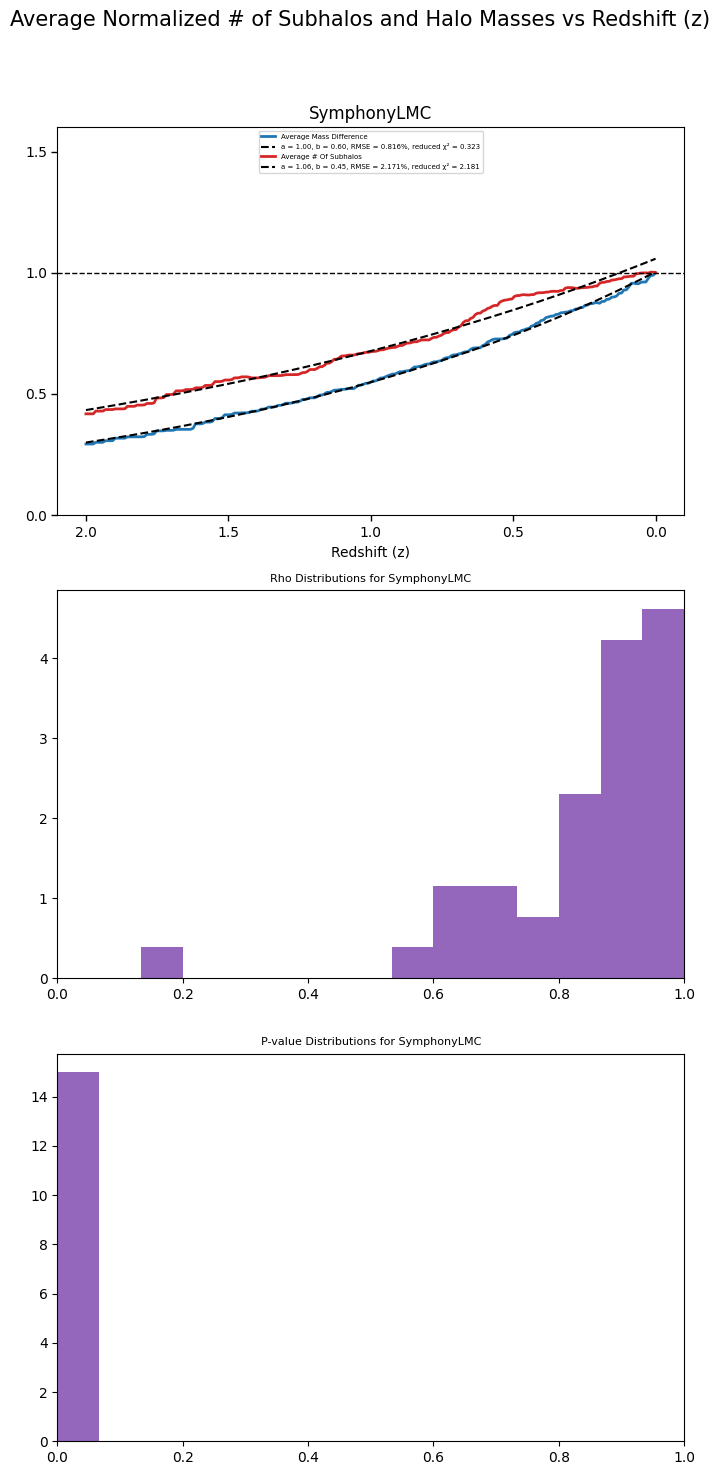

In [13]:
## defining the fitting functions from the Symphony paper
e = np.exp(1)

## FITTING FUNCTIONS:

## simple exponential decay model
def exponentialfit(x, a, b):
        return (a * e**(-1 * b * x))

## power-law + exponential correction (currently unused)
def linearcorrection(x, beta, gamma):
    return (((1 + x) ** beta) * (e ** (-1 * gamma * x)))

########################################################################################

## DATALOADER:

## useful maybe?
def get_mass_bins(suite_name, n_bins, m_max, min_particles):

    # get parameters for making histograms, as before:
    params = symlib.simulation_parameters(suite_name)
    m_min = params["mp"]/params["h100"] * min_particles
    bins = 10**np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)
    left_bins = bins[:-1]

    return {"params": params,
            "m_min": m_min,
            "m_max": m_max,
            "bins": bins,
            "left_bins": left_bins,
            "h100": params["h100"]}

## reads the raw subhalo catalog for one host
def load_host(suite_name, i_host, base_dir):

    sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
    scale_factors = symlib.scale_factors(sim_dir)
    h, hist = symlib.read_subhalos(sim_dir)

    return {"sim_dir": sim_dir,
            "scale_factors": scale_factors,
            "h": h,
            "hist": hist}


## given raw host data from load_host, compute (at each snapshot between z = 2 and z = 0):
## 1. host mass - total mass in subhalos within host rvir
## 2. number of subhalos within host rvir
## returns the raw (non-normalized) curves + the z = 0 values needed to normalize them later
def compute_host_curves(host_data):
    
    h = host_data["h"]
    scale_factors = host_data["scale_factors"]
    redshifts = np.linspace(2, 0, len(scale_factors))
    
    mass_diffs = np.zeros(len(scale_factors))
    num_subhalos = np.zeros(len(scale_factors))
    tot_subhalo_mass_at_z = 0.0

    for z_index, target_z in enumerate(redshifts):
        target_a = 1 / (1 + target_z)
        snap_index = np.argmin(np.abs(scale_factors - target_a))

        host_rvir = h["rvir"][0, snap_index]
        host_pos = h["x"][0, snap_index]
        host_mass = h["mvir"][0, snap_index]

        sub_rvir = h["rvir"][1:, snap_index]
        sub_pos = h["x"][1:, snap_index]
        sub_mass = h["mvir"][1:, snap_index]

        ok = h["ok"][1:, snap_index]
        ok_sub_pos = sub_pos[ok]
        ok_sub_rvir = sub_rvir[ok]
        ok_sub_mass = sub_mass[ok]

        ## distance from host center:
        dist = np.sqrt(np.sum((ok_sub_pos - host_pos) ** 2, axis = 1))
        inside_host_rvir = dist < (host_rvir - ok_sub_rvir)

        num_subhalos[z_index] = np.sum(inside_host_rvir)
        valid_sub_masses = np.where(inside_host_rvir, ok_sub_mass, 0.0)
        tot_subhalo_mass_at_z = np.sum(valid_sub_masses)
        mass_diffs[z_index] = host_mass - tot_subhalo_mass_at_z

    z0_mass_diff = h["mvir"][0][-1] - tot_subhalo_mass_at_z
    z0_num_nsubs = num_subhalos[-1]

    return {"redshifts": redshifts,
            "mass_diffs": mass_diffs,
            "num_subhalos": num_subhalos,
            "z0_mass_diff": z0_mass_diff,
            "z0_num_nsubs": z0_num_nsubs}

## loading all hosts:
def load_suite_hosts(suite_name, base_dir):
    n_hosts = symlib.n_hosts(suite_name)
    print(f"Loading suite {suite_name}... ({n_hosts} hosts)")

    host_curves = []
    skipped_hosts = []
    for i_host in range(n_hosts):
        print(f"Host {i_host + 1}/{n_hosts}", end = "\r", flush = True)

        try:
            host_data = load_host(suite_name, i_host, base_dir)
            host_curves.append(compute_host_curves(host_data))

        except Exception as e:
            print(f"\nSkipping host {i_host}: {e} in suite {suite_name}")
            skipped_hosts.append((suite_name, i_host))
    print(f"\nLoaded {len(host_curves)}/{n_hosts} hosts ({len(skipped_hosts)} skipped)")
    return host_curves, skipped_hosts
    
#############################################################################################

## STATISTICS:

## normalize one host's raw mass_diffs & num_subhalos to their z0 value, and compute the Spearman rank correlation between them
def normalize_host_curves(curves):

    norm_mass_diffs = curves["mass_diffs"] / curves["z0_mass_diff"]
    norm_num_nsubs = curves["num_subhalos"] / curves["z0_num_nsubs"]

    rho, p = scipy.stats.spearmanr(norm_mass_diffs / np.max(norm_mass_diffs), norm_num_nsubs / np.max(norm_num_nsubs))

    return {"redshifts": curves["redshifts"],
            "norm_mass_diffs": norm_mass_diffs,
            "norm_num_nsubs": norm_num_nsubs,
            "rho": rho,
            "p": p}

## computes R^2
#def r_squared(y_data, y_model):  
#    y_data = np.asarray(y_data)
#    y_model = np.asarray(y_model)
#    ss_res = np.sum((y_data - y_model) ** 2)
#    ss_tot = np.sum((y_data - np.mean(y_model)) ** 2)
#    return 1 - ss_res / ss_tot

## computes the root-mean-squared error (RMSE) between the suite-averaged curve and the exponential fit
def rmse(y_data, y_model):

    y_data = np.asarray(y_data)
    y_model = np.asarray(y_model)

    return np.sqrt(np.mean((y_data - y_model)**2))

## computes the reduced chi-squared (residuals normalized by per-bin uncertainty)
## sigma here is the standard error of the mean (SEM, the standard deviation across hosts divided by sqrt(n_hosts))
def reduced_chi_squared(y_data, y_model, sigma, n_params):

    y_data = np.asarray(y_data)
    y_model = np.asarray(y_model)
    sigma = np.asarray(sigma)

    valid = sigma > 0
    chi_sq = np.sum(((y_data[valid] - y_model[valid]) / sigma[valid])**2)
    dof = np.sum(valid) - n_params

    return chi_sq / dof

## given a list of raw per_host curves:
## - normalize each host
## - average across hosts
## - fit each averaged curve with an exponential model
def aggregate_suite(host_curves):
    
    normalized = [normalize_host_curves(c) for c in host_curves]

    ## MWest and EDEN have different snapshot counts compared to Symphony suites
    ## interpolating onto a common gridspace (from z = 2 to z = 0, 235 snapshots)
    common_redshifts = np.linspace(2, 0, 235)

    def interp_host(n):
        return {"norm_mass_diffs": np.interp(common_redshifts, n["redshifts"][::-1], n["norm_mass_diffs"][::-1]),
                "norm_num_nsubs":  np.interp(common_redshifts, n["redshifts"][::-1], n["norm_num_nsubs"][::-1])}

    resampled = [interp_host(n) for n in normalized]

    redshifts = common_redshifts
    norm_mass_diffs = np.array([r["norm_mass_diffs"] for r in resampled])
    norm_num_nsubs  = np.array([r["norm_num_nsubs"]  for r in resampled])
 
    avg_norm_mass_diffs = np.mean(norm_mass_diffs, axis = 0)
    avg_norm_num_nsubs = np.mean(norm_num_nsubs, axis = 0)
    std_norm_mass_diffs = np.std(norm_mass_diffs, axis = 0)
    std_norm_num_nsubs = np.std(norm_num_nsubs, axis = 0)
 
    fit_mass, _ = curve_fit(exponentialfit, redshifts, avg_norm_mass_diffs)
    fit_nsubs, _ = curve_fit(exponentialfit, redshifts, avg_norm_num_nsubs)

    n_hosts = len(host_curves)
    sigma_mass = std_norm_mass_diffs / np.sqrt(n_hosts)
    sigma_nsubs = std_norm_num_nsubs / np.sqrt(n_hosts)
    
    rmse_mass = rmse(avg_norm_mass_diffs, exponentialfit(redshifts, *fit_mass))
    rmse_nsubs = rmse(avg_norm_num_nsubs, exponentialfit(redshifts, *fit_nsubs))
    
    reduced_chisq_mass  = reduced_chi_squared(avg_norm_mass_diffs,  exponentialfit(redshifts, *fit_mass),  sigma_mass,  n_params = 2)
    reduced_chisq_nsubs = reduced_chi_squared(avg_norm_num_nsubs, exponentialfit(redshifts, *fit_nsubs), sigma_nsubs, n_params = 2)

    print(f"RMSE_mass = {(rmse_mass * 100):2f}%, χ^2_mass = {(reduced_chisq_mass):2f}")
    print(f"RMSE_nsubs = {(rmse_nsubs * 100):2f}%, χ^2_nsubs = {(reduced_chisq_nsubs):2f}")
 
    return {"redshifts": redshifts,
            "avg_norm_mass_diffs": avg_norm_mass_diffs,
            "avg_norm_num_nsubs": avg_norm_num_nsubs,
            "std_norm_mass_diffs": std_norm_mass_diffs,
            "std_norm_num_nsubs": std_norm_num_nsubs,
            "fit_mass": fit_mass,
            "fit_nsubs": fit_nsubs,
            "rmse_mass": rmse_mass,
            "rmse_nsubs": rmse_nsubs,
            "reduced_chisq_mass": reduced_chisq_mass,
            "reduced_chisq_nsubs": reduced_chisq_nsubs,
            "rho_suite": [n["rho"] for n in normalized],
            "p_suite": [n["p"] for n in normalized]}

##################################################################################################################################

## PLOTTER:

## fill in one column of the 3-row figure (curves, rho hist, p hist for a single suite)
def plot_suite(axs, suite_index, suite_name, suite_result, colors):

    redshifts = suite_result["redshifts"]
    color = colors[suite_name]

    ax = axs[0, suite_index]
    ax.plot(redshifts, suite_result["avg_norm_mass_diffs"], color = "tab:blue", lw = 2, label = "Average Mass Difference")
    #ax.fill_between(redshifts, suite_result["avg_norm_mass_diffs"] + suite_result["std_norm_mass_diffs"],
    #                suite_result["avg_norm_mass_diffs"] - suite_result["std_norm_mass_diffs"], color = "lightcyan")
    ax.plot(redshifts, exponentialfit(redshifts, *suite_result["fit_mass"]), color = "black", linestyle = "--",
            label = f"a = {suite_result['fit_mass'][0]:.2f}, b = {suite_result['fit_mass'][1]:.2f}, "
                    f"RMSE = {(suite_result['rmse_mass']*100):.3f}%, reduced \u03C7\u00b2 = {suite_result['reduced_chisq_mass']:.3f}")

    ax.plot(redshifts, suite_result["avg_norm_num_nsubs"], color = "tab:red", lw = 2,
            label = "Average # Of Subhalos")
    #ax.fill_between(redshifts, suite_result["avg_norm_num_nsubs"] + suite_result["std_norm_num_nsubs"],
    #                suite_result["avg_norm_num_nsubs"] - suite_result["std_norm_num_nsubs"], color = "mistyrose")
    ax.plot(redshifts, exponentialfit(redshifts, *suite_result["fit_nsubs"]), color = "black", linestyle = "--",
            label = f"a = {suite_result['fit_nsubs'][0]:.2f}, b = {suite_result['fit_nsubs'][1]:.2f}, "
                    f"RMSE = {(suite_result['rmse_nsubs']*100):.3f}%, reduced \u03C7\u00b2 = {suite_result['reduced_chisq_nsubs']:.3f}")

    ax.invert_xaxis()
    ax.set_xlabel("Redshift (z)")
    ax.set_ylim(0.0, 1.6)
    ax.axhline(y = 1, color = "black", lw = 1, linestyle = "--")
    ax.locator_params(axis = "x", nbins = 5)
    ax.locator_params(axis = "y", nbins = 5)
    ax.tick_params(axis = "both", which = "major", length = 4, width = 1, direction = "out")
    ax.legend(fontsize = 5, loc = "upper center")
    ax.set_title(suite_name)

    ax_rho = axs[1, suite_index]
    ax_rho.hist(suite_result["rho_suite"], bins = 15, range = (0, 1), color = color, density = True)
    ax_rho.set_xlim(0, 1)
    ax_rho.set_title(f"Rho Distributions for {suite_name}", fontsize = 8)

    ax_p = axs[2, suite_index]
    ax_p.hist(suite_result["p_suite"], bins = 15, range = (0, 1), color = color, density = True)
    ax_p.set_xlim(0, 1)
    ax_p.set_title(f"P-value Distributions for {suite_name}", fontsize = 8)


## plotting all suites:
def plot_all_suites(suite_results, colors):

    suite_names = list(suite_results.keys())
    ncols = len(suite_names)
    nrows = 3
    fig, axs = plt.subplots(ncols = ncols, nrows = nrows, figsize = (7 * ncols, 5 * nrows), squeeze = False)

    for suite_index, suite_name in enumerate(suite_names):
        plot_suite(axs, suite_index, suite_name, suite_results[suite_name], colors)
        
    fig.suptitle("Average Normalized # of Subhalos and Halo Masses vs Redshift (z)", fontsize = 15)
    fig.tight_layout(rect = [0, 0, 1, 0.95])  ## leaves room for suptitle at the top
    #fig.savefig("Nsubs vs. Host Masses [all suites!!] (RMSE + reduced χ^2).png", bbox_inches = "tight")
    plt.show()

    return fig, axs

#######################################################################################################################

## ENTRYPOINT:

def run_all_suites(suite_list, base_dir, colors):
    suite_results = {}
    all_skipped = []
    for suite_name in suite_list:
        host_curves, skipped_hosts = load_suite_hosts(suite_name, base_dir)
        all_skipped.extend(skipped_hosts)
        suite_results[suite_name] = aggregate_suite(host_curves)

    if all_skipped:
        print(f"\nSkipped hosts across all suites:")
        for suite_name, i_host in all_skipped:
            print(f"{suite_name}, host {i_host}")
 
    fig, axs = plot_all_suites(suite_results, colors)
    return fig, axs, suite_results, all_skipped
 
 
if __name__ == "__main__":
    fig, axs, suite_results, all_skipped = run_all_suites(suite_list, base_dir, colors)


# look at p-values and try to resolve the question regarding the delta-function-like behavior --> probably unphysical??
# upgrade the distance calculation and factor in the possibility of there being subhalos that are partially inside the host halo, especially at high redshift

<a id = "norm_nsubs_vs_norm_host_mass"></a>
## Nsubs(z)/Nsubs(z=0) vs. Host Mass(z)/Host Mass(z=0):
[Back to Table of Contents](#table_of_contents)

* Individual hosts as a faint line, mean as a bold line (colored by suite) --> add 16-84% confidence as well maybe
* Time series of points starting at (0, 0) and ending at (1, 1)
* Perfect correlation would traverse along the 1-to-1 line

Goal: assess how well MAH predicts Nsub on an individual host and an average basis

Loading suite SymphonyLMC... (39 hosts)
Host 39/39
Loaded 39/39 hosts (0 skipped)
Loading suite SymphonyMilkyWay... (45 hosts)
Host 45/45
Loaded 45/45 hosts (0 skipped)
Loading suite MWest... (20 hosts)
Host 20/20
Loaded 20/20 hosts (0 skipped)
Loading suite SymphonyGroup... (49 hosts)
Host 49/49
Loaded 49/49 hosts (0 skipped)
Loading suite SymphonyLCluster... (33 hosts)
Host 33/33
Loaded 33/33 hosts (0 skipped)
Loading suite SymphonyCluster... (81 hosts)
Host 81/81
Loaded 81/81 hosts (0 skipped)


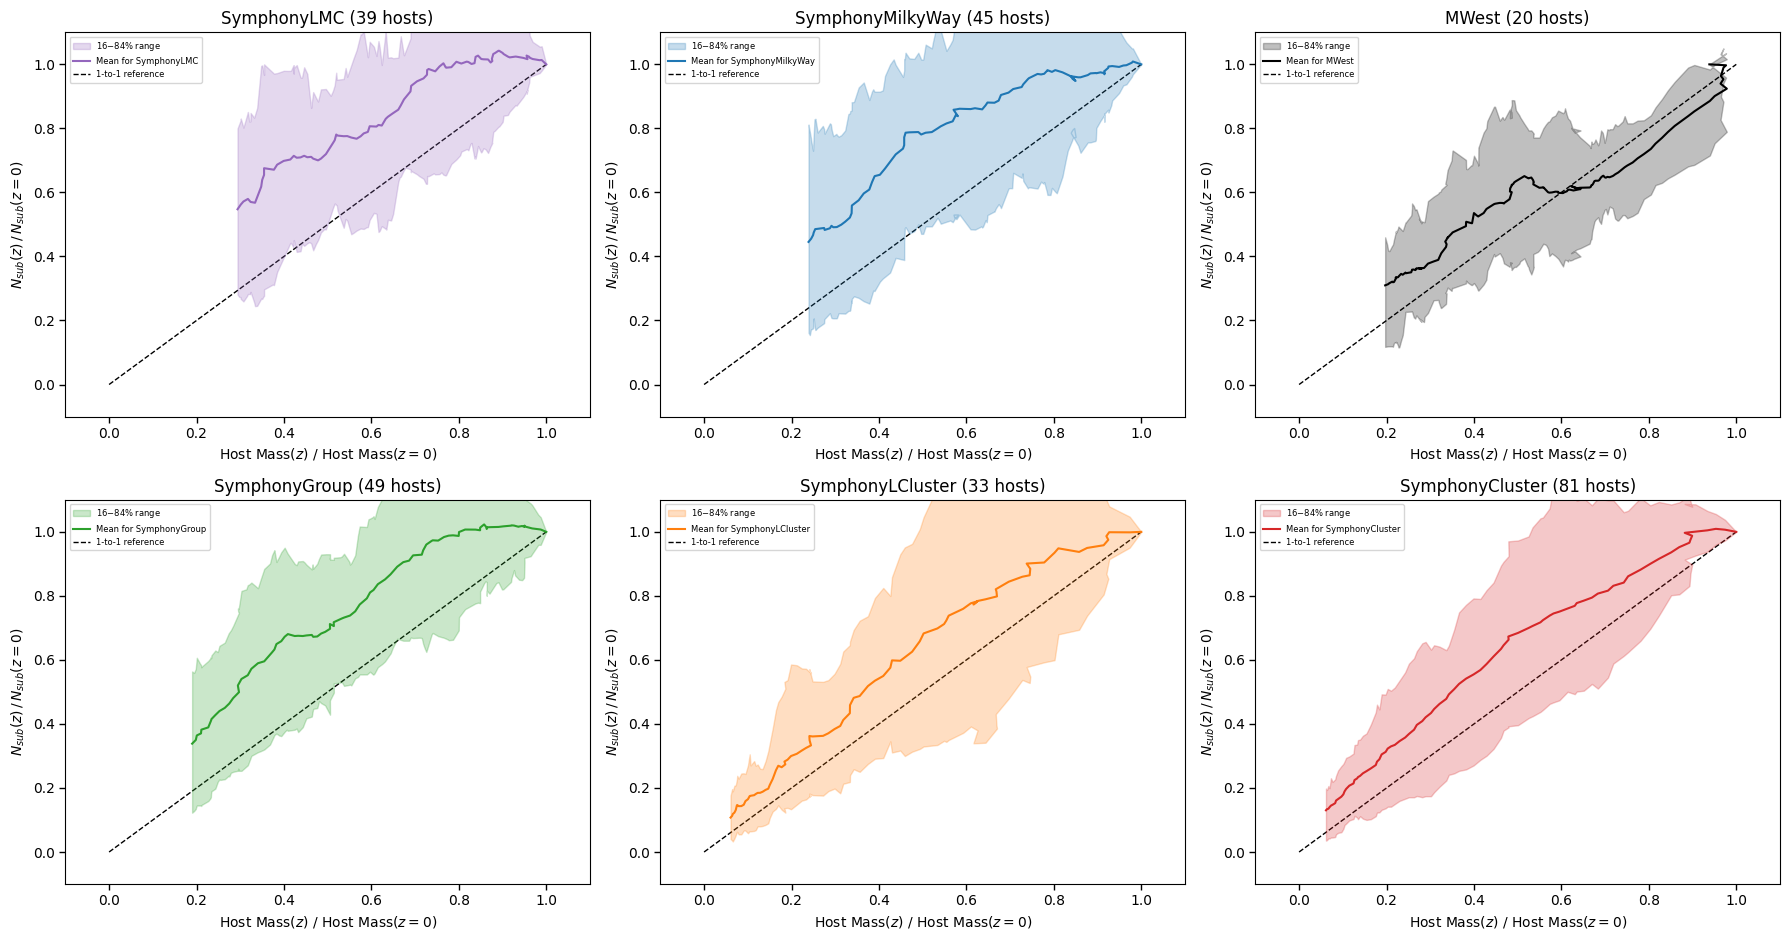

In [37]:
## DATALOADER:

def get_mass_bins(suite_name, n_bins, m_max, min_particles):

    # get parameters for making histograms, as before:
    params = symlib.simulation_parameters(suite_name)
    m_min = params["mp"]/params["h100"] * min_particles
    bins = 10**np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)
    left_bins = bins[:-1]

    return {"params": params,
            "m_min": m_min,
            "m_max": m_max,
            "bins": bins,
            "left_bins": left_bins,
            "h100": params["h100"]}


def load_host(suite_name, i_host, base_dir):

    sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
    scale_factors = symlib.scale_factors(sim_dir)
    h, hist = symlib.read_subhalos(sim_dir)

    return {"sim_dir": sim_dir,
            "suite_name": suite_name,
            "scale_factors": scale_factors,
            "h": h,
            "hist": hist}


def compute_host_curves(host_data, min_particles = 300):
    
    h = host_data["h"]
    scale_factors = host_data["scale_factors"]
    redshifts = np.linspace(2, 0, len(scale_factors))

    params = symlib.simulation_parameters(host_data["suite_name"])
    resolution_cut = params["mp"] / params["h100"] * min_particles
    
    mass_diffs = np.zeros(len(scale_factors))
    num_subhalos = np.zeros(len(scale_factors))
    tot_subhalo_mass_at_z = 0.0

    for z_index, target_z in enumerate(redshifts):
        
        target_a = 1 / (1 + target_z)
        snap_index = np.argmin(np.abs(scale_factors - target_a))

        host_rvir = h["rvir"][0, snap_index]
        host_pos = h["x"][0, snap_index]
        host_mass = h["mvir"][0, snap_index]

        sub_rvir = h["rvir"][1:, snap_index]
        sub_pos = h["x"][1:, snap_index]
        sub_mass = h["mvir"][1:, snap_index]

        ok = h["ok"][1:, snap_index]
        above_res_limit = sub_mass >= resolution_cut

        ## applying both the ok cut and the 300 particles cut
        valid = ok & above_res_limit
        
        ok_sub_pos = sub_pos[valid]
        ok_sub_rvir = sub_rvir[valid]
        ok_sub_mass = sub_mass[valid]

        ## distance from host center:
        dist = np.sqrt(np.sum((ok_sub_pos - host_pos) ** 2, axis = 1))
        inside_host_rvir = dist < (host_rvir - ok_sub_rvir)

        num_subhalos[z_index] = np.sum(inside_host_rvir)
        valid_sub_masses = np.where(inside_host_rvir, ok_sub_mass, 0.0)
        tot_subhalo_mass_at_z = np.sum(valid_sub_masses)
        mass_diffs[z_index] = host_mass - tot_subhalo_mass_at_z

    z0_mass_diff = h["mvir"][0][-1] - tot_subhalo_mass_at_z
    z0_num_nsubs = num_subhalos[-1]

    return {"redshifts": redshifts,
            "mass_diffs": mass_diffs,
            "num_subhalos": num_subhalos,
            "z0_mass_diff": z0_mass_diff,
            "z0_num_nsubs": z0_num_nsubs}

## loading all hosts:
def load_suite_hosts(suite_name, base_dir):
    n_hosts = symlib.n_hosts(suite_name)
    print(f"Loading suite {suite_name}... ({n_hosts} hosts)")

    host_curves = []
    skipped_hosts = []
    for i_host in range(n_hosts):
        print(f"Host {i_host + 1}/{n_hosts}", end = "\r", flush = True)

        try:
            host_data = load_host(suite_name, i_host, base_dir)
            host_curves.append(compute_host_curves(host_data))

        except Exception as e:
            print(f"\nSkipping host {i_host}: {e} in suite {suite_name}")
            skipped_hosts.append((suite_name, i_host))
    print(f"\nLoaded {len(host_curves)}/{n_hosts} hosts ({len(skipped_hosts)} skipped)")
    return host_curves, skipped_hosts
    
#############################################################################################

## STATISTICS:

## normalize one host's raw mass_diffs & num_subhalos to their z0 value, and compute the Spearman rank correlation between them
def normalize_host_curves(curves):

    norm_mass_diffs = curves["mass_diffs"] / curves["z0_mass_diff"]
    norm_num_nsubs = curves["num_subhalos"] / curves["z0_num_nsubs"]

    rho, p = scipy.stats.spearmanr(norm_mass_diffs / np.max(norm_mass_diffs), norm_num_nsubs / np.max(norm_num_nsubs))

    return {"redshifts": curves["redshifts"],
            "norm_mass_diffs": norm_mass_diffs,
            "norm_num_nsubs": norm_num_nsubs,
            "rho": rho,
            "p": p}


## interpolate one (already normalized) host's curves onto a common redshift grid
def resample_host_to_grid(normalized_curves, common_redshifts):
    return {"norm_mass_diffs": np.interp(common_redshifts, normalized_curves["redshifts"][::-1],
                                          normalized_curves["norm_mass_diffs"][::-1]),
            "norm_num_nsubs":  np.interp(common_redshifts, normalized_curves["redshifts"][::-1],
                                          normalized_curves["norm_num_nsubs"][::-1])}


def aggregate_suite_trajectory(host_curves, n_grid = 200):

    ## MWest and EDEN have different snapshot counts compared to Symphony suites
    ## interpolating onto a common gridspace (from z = 2 to z = 0, n_grid = number of snapshots)
    common_redshifts = np.linspace(2, 0, n_grid)

    normalized = [normalize_host_curves(c) for c in host_curves]
    resampled = [resample_host_to_grid(n, common_redshifts) for n in normalized]

    mass_matrix = np.array([r["norm_mass_diffs"] for r in resampled])
    nsubs_matrix = np.array([r["norm_num_nsubs"] for r in resampled])

    mean_mass = np.mean(mass_matrix, axis = 0)
    mean_nsubs = np.mean(nsubs_matrix, axis = 0)

    p16_nsubs, p84_nsubs = np.percentile(nsubs_matrix, [16, 84], axis = 0)
 
    return {"redshifts": common_redshifts,
            "mass_matrix": mass_matrix,
            "nsubs_matrix": nsubs_matrix,
            "mean_mass": mean_mass,
            "mean_nsubs": mean_nsubs,
            "p16_nsubs": p16_nsubs,
            "p84_nsubs": p84_nsubs,
            "n_hosts": len(host_curves)}

##################################################################################################################################

## PLOTTER:

## fill in one panel: Nsubs(z)/Nsubs(z=0) vs Mass(z)/Mass(z=0) for a single suite
def plot_suite_trajectory(ax, suite_name, suite_result, colors):

    color = colors[suite_name]
    mass_matrix = suite_result["mass_matrix"]
    nsubs_matrix = suite_result["nsubs_matrix"]

    ## faint individual host traces
    #for i in range(suite_result["n_hosts"]):
    #    ax.plot(mass_matrix[i], nsubs_matrix[i], color = color, alpha = 0.15, lw = 0.75, zorder = 1)

    ## 16-84% envelope on Nsubs
    ax.fill_between(suite_result["mean_mass"], suite_result["p16_nsubs"], suite_result["p84_nsubs"],
                    color = color, alpha = 0.25, zorder = 2, label = "16$-$84% range")

    ## mean trajectory, solid/bold
    ax.plot(suite_result["mean_mass"], suite_result["mean_nsubs"], color = color, lw = 1.5, zorder = 3, label = f"Mean for {suite_name}")

    ## 1-to-1 reference line
    ax.plot([0, 1], [0, 1], color = "black", linestyle = "--", lw = 1, zorder = 0, label = "1-to-1 reference")
    
    ax.set_xlabel(r"Host Mass($z$) / Host Mass($z=0$)")
    ax.set_ylabel(r"$N_{sub}(z)\,/\,N_{sub}(z=0)$")
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.set_title(f"{suite_name} ({suite_result['n_hosts']} hosts)")
    ax.legend(fontsize = 6, loc = "upper left")
    ax.tick_params(axis = "both", which = "major", length = 4, width = 1, direction = "out")


## plotting all suites:
def plot_all_suites_trajectories(suite_results, colors, max_cols = 3):

    suite_names = list(suite_results.keys())
    n_suites = len(suite_names)
    ncols = min(max_cols, n_suites)
    nrows = int(np.ceil(n_suites / ncols))
    
    fig, axs = plt.subplots(ncols = ncols, nrows = nrows, figsize = (6 * ncols, 5 * nrows), squeeze = False)
    flat_axs = axs.flatten()

    for i, suite_name in enumerate(suite_names):
        plot_suite_trajectory(flat_axs[i], suite_name, suite_results[suite_name], colors)

    ## delete any unused axes
    for j in range(n_suites, len(flat_axs)):
        fig.delaxes(flat_axs[j])
        
    #fig.suptitle(r"$N_{sub}$ vs. Host Mass Growth Trajectories (normalized to $z=0$)", fontsize = 15)
    fig.tight_layout(rect = [0, 0, 1, 0.95])
    fig.savefig("Nsub(z) over Nsub(z=0) vs Host Mass(z) over Host Mass(z=0) [hosts hidden].png", dpi = 300, bbox_inches = "tight")
    plt.show()

    return fig, axs

#######################################################################################################################

## ENTRYPOINT:

def run_all_suites(suite_list, base_dir, colors):
    
    suite_results = {}
    all_skipped = []
    
    for suite_name in suite_list:
        host_curves, skipped_hosts = load_suite_hosts(suite_name, base_dir)
        all_skipped.extend(skipped_hosts)
        suite_results[suite_name] = aggregate_suite_trajectory(host_curves)

    if all_skipped:
        print(f"\nSkipped hosts across all suites:")
        for suite_name, i_host in all_skipped:
            print(f"{suite_name}, host {i_host}")
 
    fig, axs = plot_all_suites_trajectories(suite_results, colors)
    return fig, axs, suite_results, all_skipped
 
 
if __name__ == "__main__":
    fig, axs, suite_results, all_skipped = run_all_suites(suite_list, base_dir, colors)

<a id = "smooth_vs_clumpy_accretion"></a>
## Smooth vs. Clumpy Accretion of Particles
[Back to Table of Contents](#table_of_contents)

Another interesting question is "what fraction of the host's mass is made of the "smooth" background particles being accreted onto the host versus "bursty" particles being accreted when subhalos fall in?"

The expectation is that because dark matter halos are supported against gravitational collapse by the random motions of the particles, all of the halos (including the host) should be made of mostly "smooth" particles, with only a small number of the particles being "bursty" or "clumpy." The host is so large and massive that it can "afford" to have some inhomogeneities in it, but the subhalos are all "smooth" on the inside.

The infalling particles are a different fraction of "smooth" versus "clumpy," possibly closer to 50-50? However, due to tidal stripping, the "clumpy" particles that belong to a particular subhalo become "smooth" as they get stripped away.

First, let's look at only the particles belonging to the main host (labeled as being part of the host by the halo finder, and also inside the host virial radius at a given time), and let's look at the fraction of the host mass that is also contained in subhalos. We will assume that the remaining mass is all "smooth" particles that aren't part of any substructure.

Starting on suite SymphonyLMC...
Starting on suite SymphonyMilkyWay...
Current host: 1/45

C:\Users\steph\AppData\Local\Temp\ipykernel_4016\2480898267.py:102: RuntimeWarning: Mean of empty slice
  mean_clumpy = np.nanmean(all_clumpy, axis = 0)
C:\Users\steph\AppData\Local\Temp\ipykernel_4016\2480898267.py:106: RuntimeWarning: Mean of empty slice
  mean_smooth = np.nanmean(all_smooth, axis = 0)


Starting on suite MWest...
Starting on suite SymphonyGroup...
Starting on suite SymphonyLCluster...
Starting on suite SymphonyCluster...
Current host: 81/81

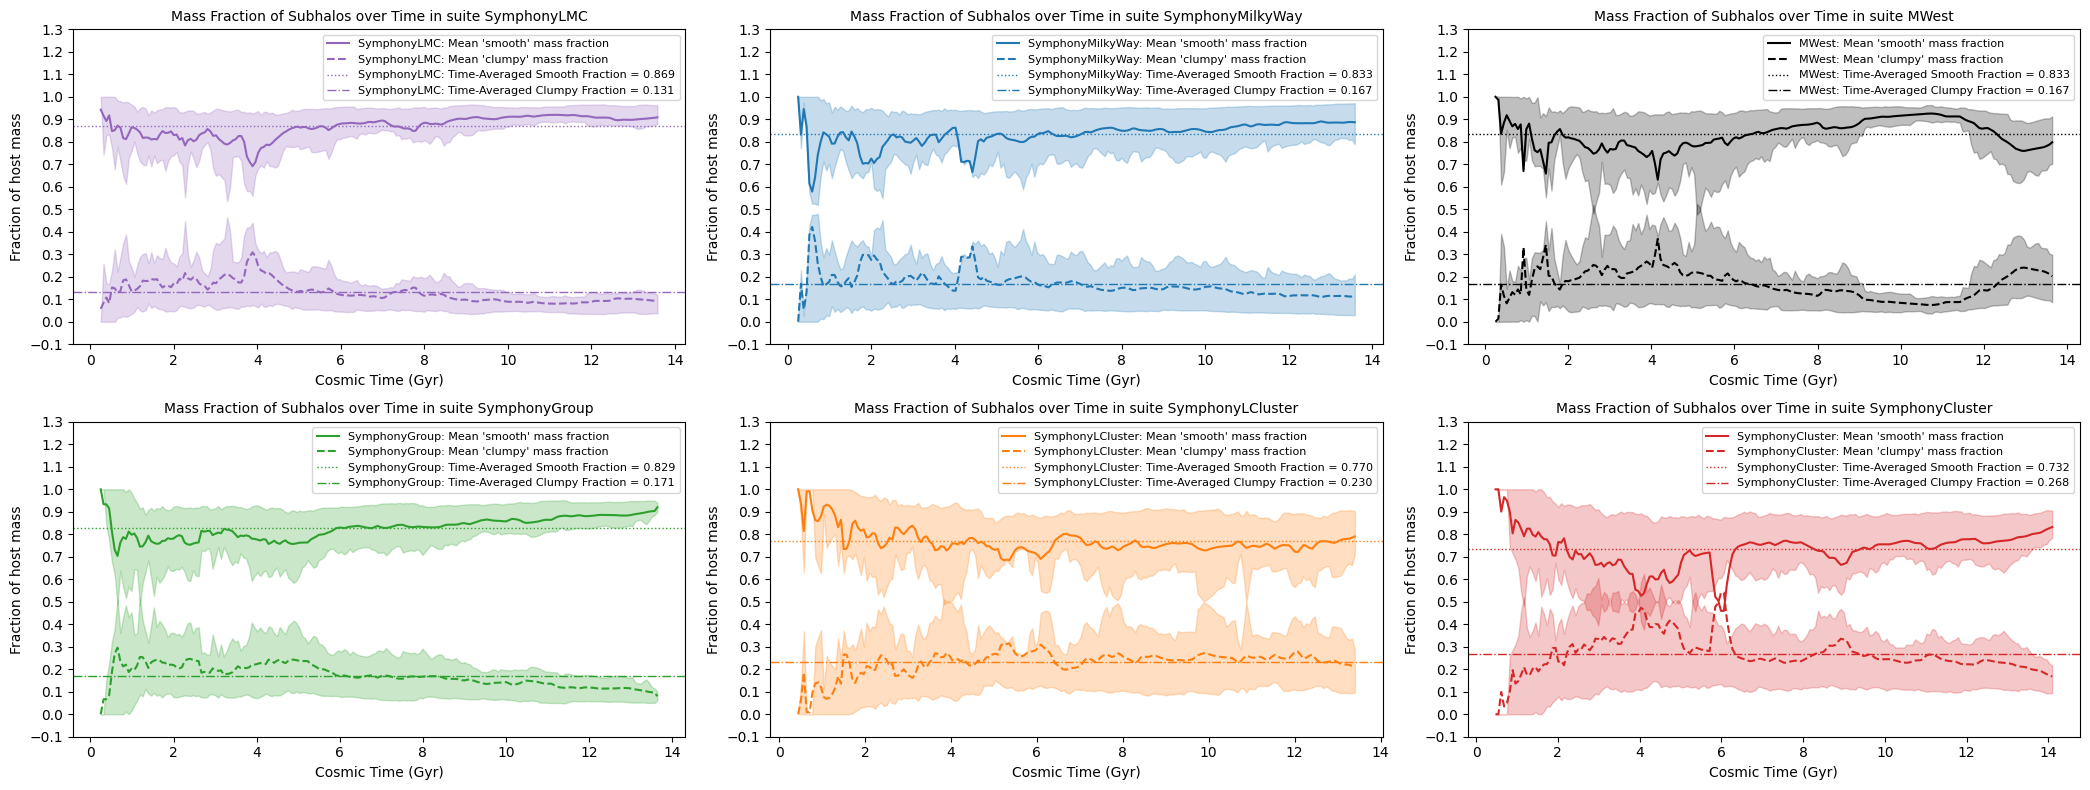

In [54]:
n_suites = len(suite_list)
ncols = 3 if n_suites > 1 else 1
nrows = int(np.ceil(n_suites / ncols))

n_grid = 200  # number of points in the common cosmic-time grid

fig, axes = plt.subplots(nrows, ncols, figsize = (7 * ncols, 4 * nrows), squeeze = False)
axes_flat = axes.flatten()

for suite_index, suite_name in enumerate(suite_list):
    ax = axes_flat[suite_index]

    print(f"Starting on suite {suite_name}...")

    n_hosts = symlib.n_hosts(suite_name)

    all_clumpy = []
    all_smooth = []

    common_time_grid = None
    cosmo = None

    for i_host in range(n_hosts):

        print(f"Current host: {i_host + 1}/{n_hosts}", end = "\r", flush = True)

        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        scale_factors = symlib.scale_factors(sim_dir)
        snapshots = np.arange(0, len(scale_factors), 1)
        params = symlib.simulation_parameters(sim_dir)

        mp = params["mp"] / params["h100"]
        particle_cut = 300 * mp

        h, hist = symlib.read_subhalos(sim_dir)

        ## 300 particles and "ok" cut for the host and subhalos:
        ok = h["ok"]
        mvir = h["mvir"]

        host_ok = ok[0, :]
        host_mass_all_snaps = mvir[0, :]

        sub_ok = ok[1:, :]
        sub_mass = mvir[1:, :]

        ## position cut for subhalos:
        host_x = h["x"][0, :]
        sub_x = h["x"][1:, :]
        host_rvir = h["rvir"][0, :]

        r = np.sqrt(np.sum(sub_x**2, axis = -1))
        inside_rvir = r <= host_rvir

        mass_cut = sub_mass >= particle_cut
        valid = sub_ok & inside_rvir & mass_cut
        masked_sub_mass = np.where(valid, sub_mass, 0.0)

        ## total mass of subhalos that meet these criteria (on a per-snapshot basis):
        sub_mass_all_snaps = np.sum(masked_sub_mass, axis = 0)
        
        ## apply the "ok" cut and the 300-particle cut to the host:
        host_mass_cut = host_mass_all_snaps >= particle_cut
        valid_host = host_ok & host_mass_cut & (host_mass_all_snaps > 0)

        ## explicit clumpy and smooth fractions
        clumpy_frac = np.full_like(host_mass_all_snaps, np.nan, dtype = float)
        clumpy_frac[valid_host] = sub_mass_all_snaps[valid_host] / host_mass_all_snaps[valid_host]
        
        smooth_frac = np.full_like(host_mass_all_snaps, np.nan, dtype = float)
        smooth_frac[valid_host] = 1.0 - clumpy_frac[valid_host]

        ## convert this host's own scale factors to cosmic time
        if cosmo is None:
            cosmo = FlatLambdaCDM(H0 = params["h100"] * 100, Om0 = params["Om0"])
            ## build the common 200-point cosmic-time grid once per suite,
            ## spanning from z_max down to z = 0 using this suite's cosmology
            t_min = cosmo.age(z_max).value
            t_max = cosmo.age(0.0).value
            common_time_grid = np.linspace(t_min, t_max, n_grid)

        redshift_host = 1.0 / scale_factors - 1.0
        cosmic_time_host = cosmo.age(redshift_host).value  # Gyr, monotonically increasing

        ## interpolate this host's fractions onto the common grid.
        ## only interpolate over the host's valid (non-NaN) points; anything outside that valid time range is left as NaN (not extrapolated).
        valid_idx = ~np.isnan(clumpy_frac)
        if valid_idx.sum() < 2:
            # not enough valid points to interpolate this host at all — skip it
            continue

        interp_clumpy = np.interp(common_time_grid, cosmic_time_host[valid_idx], clumpy_frac[valid_idx], left = np.nan, right = np.nan)
        interp_smooth = np.interp(common_time_grid, cosmic_time_host[valid_idx], smooth_frac[valid_idx], left = np.nan, right = np.nan)
        
        all_clumpy.append(interp_clumpy)
        all_smooth.append(interp_smooth)

    ## stack into (n_hosts, n_snaps) arrays and average over hosts, ignoring NaNs
    all_clumpy = np.vstack(all_clumpy)
    all_smooth = np.vstack(all_smooth)

    mean_clumpy = np.nanmean(all_clumpy, axis = 0)
    p16_clumpy = np.nanpercentile(all_clumpy, 16, axis = 0)
    p84_clumpy = np.nanpercentile(all_clumpy, 84, axis = 0)
    
    mean_smooth = np.nanmean(all_smooth, axis = 0)
    p16_smooth = np.nanpercentile(all_smooth, 16, axis = 0)
    p84_smooth = np.nanpercentile(all_smooth, 84, axis = 0)

    ax.plot(common_time_grid, mean_smooth, color = colors[suite_name], lw = 1.5, label = f"{suite_name}: Mean 'smooth' mass fraction ")
    ax.fill_between(common_time_grid, p16_smooth, p84_smooth, color = colors[suite_name], alpha = 0.25)

    ax.plot(common_time_grid, mean_clumpy, color = colors[suite_name], lw = 1.5, linestyle = "--", label = f"{suite_name}: Mean 'clumpy' mass fraction")
    ax.fill_between(common_time_grid, p16_clumpy, p84_clumpy, color = colors[suite_name], alpha = 0.25)

    ## plotting horizontal lines for the time-averaged fractions over all snapshots (ignoring NaNs)
    time_avg_smooth = np.nanmean(mean_smooth)
    time_avg_clumpy = np.nanmean(mean_clumpy)

    ax.axhline(time_avg_smooth, color = colors[suite_name], lw = 1.0, linestyle = ":",
               label = f"{suite_name}: Time-Averaged Smooth Fraction = {time_avg_smooth:.3f}")
    ax.axhline(time_avg_clumpy, color = colors[suite_name], lw = 1.0, linestyle = "-.",
               label = f"{suite_name}: Time-Averaged Clumpy Fraction = {time_avg_clumpy:.3f}")

    ax.set_xlabel("Cosmic Time (Gyr)")
    ax.set_ylabel("Fraction of host mass")
    ax.set_ylim(-0.1, 1.3)
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
    ax.set_title(f"Mass Fraction of Subhalos over Time in suite {suite_name}", fontsize = 10)
    ax.legend(loc = "best", fontsize = 8)

## remove any unused axes (when n_suites doesn't evenly fill the grid)
for j in range(n_suites, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.savefig("test.png")
plt.show()

<a id = "correlation_functions"></a>
## Correlation Functions
[Back to Table of Contents](#table_of_contents)

[d'Souza & Bell (2021)](https://arxiv.org/pdf/2104.13249) describe a cross-correlation function (estimator 𝜉 (𝑡) = (𝑁_𝑅/𝑁_𝑆) * (𝐷𝐷(𝑡)/𝐷𝑅(𝑡))− 1). N_R is the "number of points in the random catalog," N_S is the "number of subhalos", DD(t) is the "count of pairs (subhalos-massive progenitors) accreted within time t and t + dt," and DR(t) is the "count of pairs (random-massive progenitors).

* First, we need to create this random catalog (d'Souza & Bell Figure 1)
* Next, we need to use it to generate their cross-correlation function using the random catalog and the estimator

The full workflow goes as follows:
1. Use subhalo Mpeaks to classify "massive progenitors" (subhalos with Mpeak >= 0.1 Mpeak_host). The general subhalo population has mass cuts derived from the number of particles corresponding to 1e9 (physical) Msun for SymphonyMilkyWay (i.e N_particles * particle_mass for that suite). We also need to exclude the massive progenitors from the list of "associated" subhalos, to avoid trivial 0-lag self-pairings
2. Build Figure 1 (general subhalo population, separated into "all," "destroyed by z = 0," "surviving at z = 0," and "surviving inside host Rvir at z = 0")
3. Use the Deason et. al. criterion described in the paper to tag subhalos as "associated." Associated subhalos have the condition that they were inside a massive progenitor's Rvir for at least 1 Gyr preceding the subhalo's infall into the main host. This creates two, related populations: all subhalos regardless of association, and subhalos "associated" with some massive progenitor. The Deason tagging does NOT exclude any subhalos, it's just another, stricter subset of the subhalos.
4. Compute the cross-correlation using the estimator $\xi(t)=\frac{N_R}{N_S} \frac{DD(t)}{DR(t)} - 1$. There will be two separate DD(t) computations, one built from all subhalos and another from only Deason-tagged subhalos. Bootstrap resampling of the random catalog (Figure 1) creates DR(t).

Reference suite: SymphonyMilkyWay
Particle mass in reference suite = 4.028e+05 Msun
1e9 Msun = 2482.4 particles is now the fixed particle count cutoff applied to every suite

Reference host Rvir (z=0, SymphonyMilkyWay host 0) = 272.0 kpc
80 kpc = 0.2941 x Rvir -- this FRACTION is now applied to every host's own Rvir to get its equivalent '80 kpc' point
Loading suite SymphonyLMC...
SymphonyLMC: particle mass = 5.035e+04 Msun, cutoff = 2482 particles = 1.250e+08 Msun (OK)
Starting on host 39/39
Total: 2247
Destroyed: 1081
Surviving: 1166
Surviving inside rvir: 885
Massive progenitors: 50, Subhaloes (MPs excluded): 2197, Deason-tagged: 125
MPs with valid crossing time (0.2941 x host Rvir): 46, without: 4
Destroyed subhaloes with valid destruction time (Fig 15 population): 1040

Loading suite SymphonyMilkyWay...
SymphonyMilkyWay: particle mass = 4.028e+05 Msun, cutoff = 2482 particles = 1.000e+09 Msun (OK)
Starting on host 45/45
Total: 3764
Destroyed: 1739
Surviving: 2025
Surviving inside 

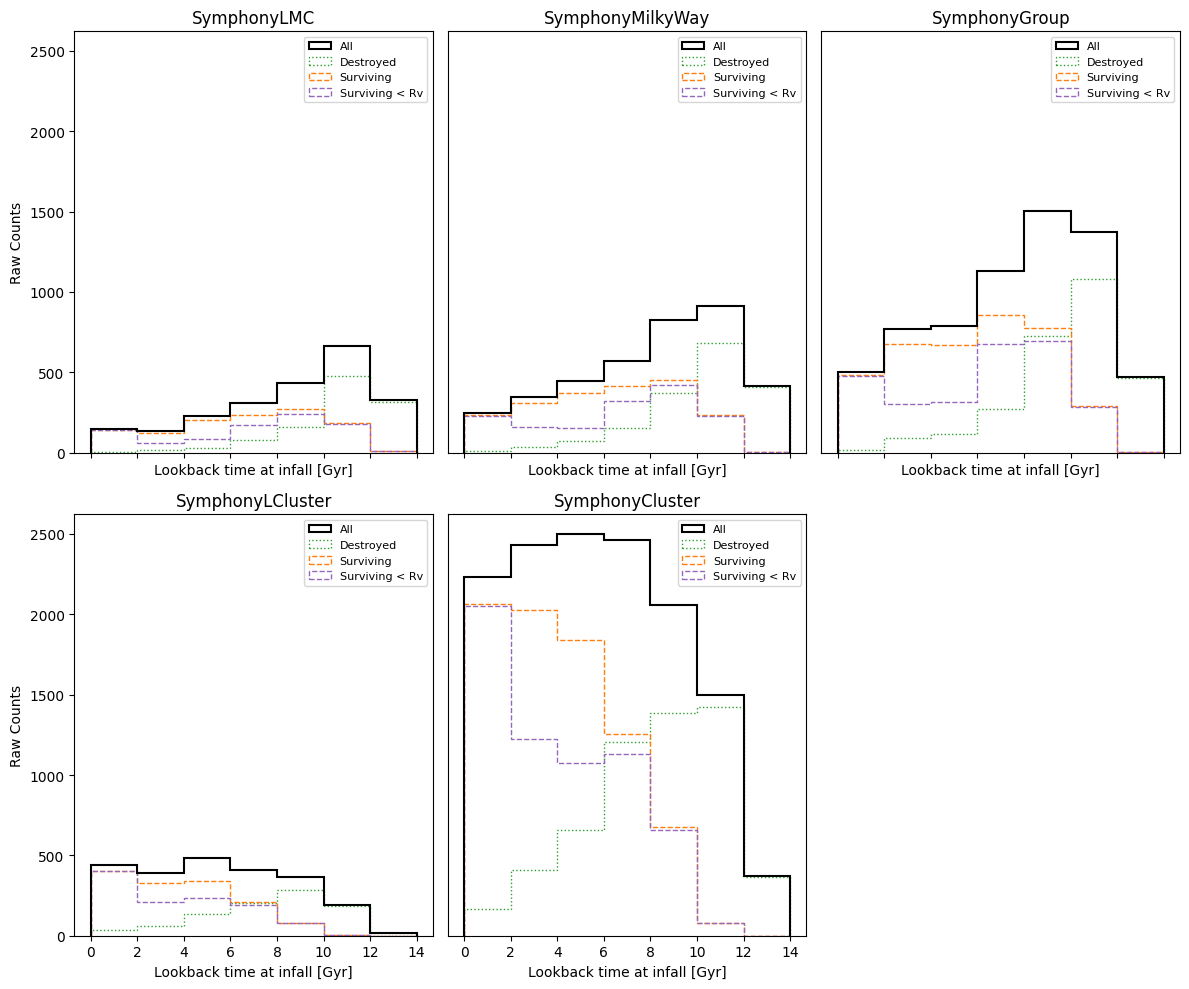

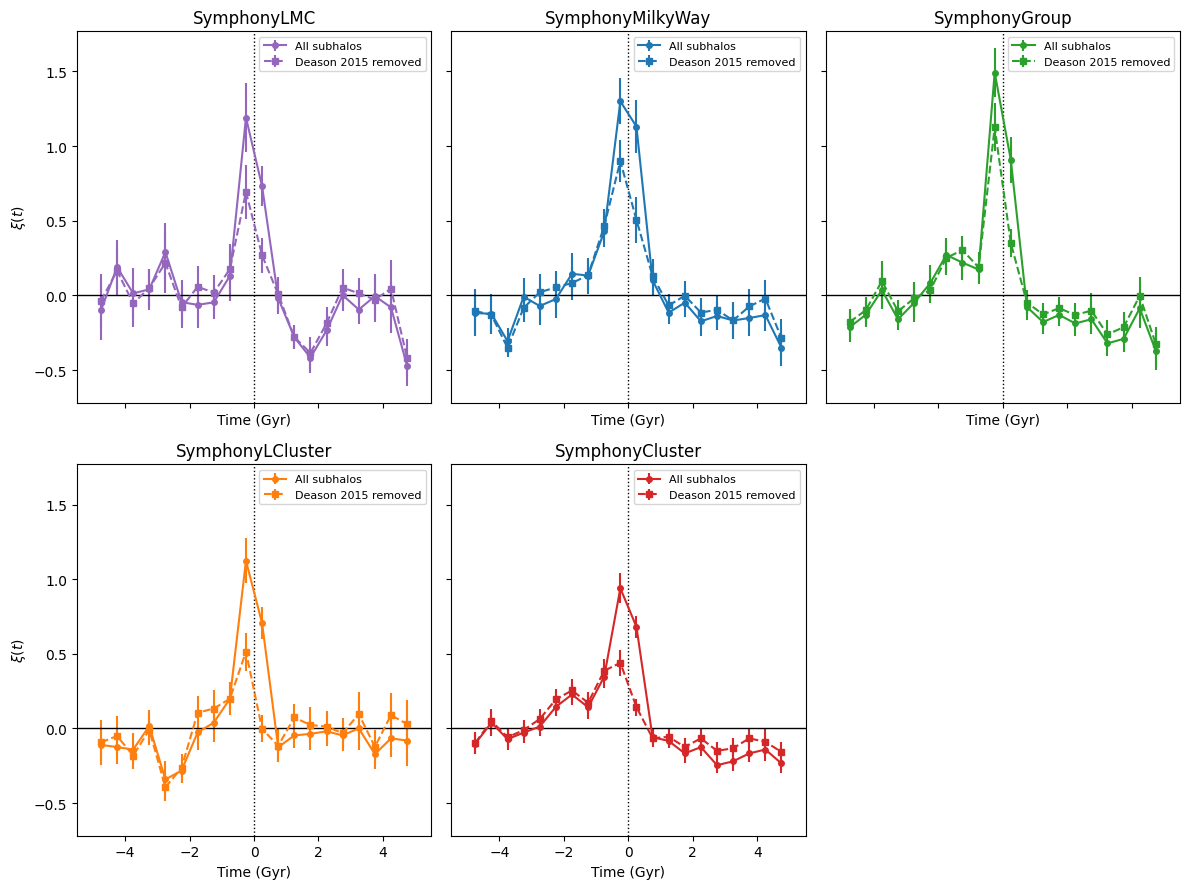

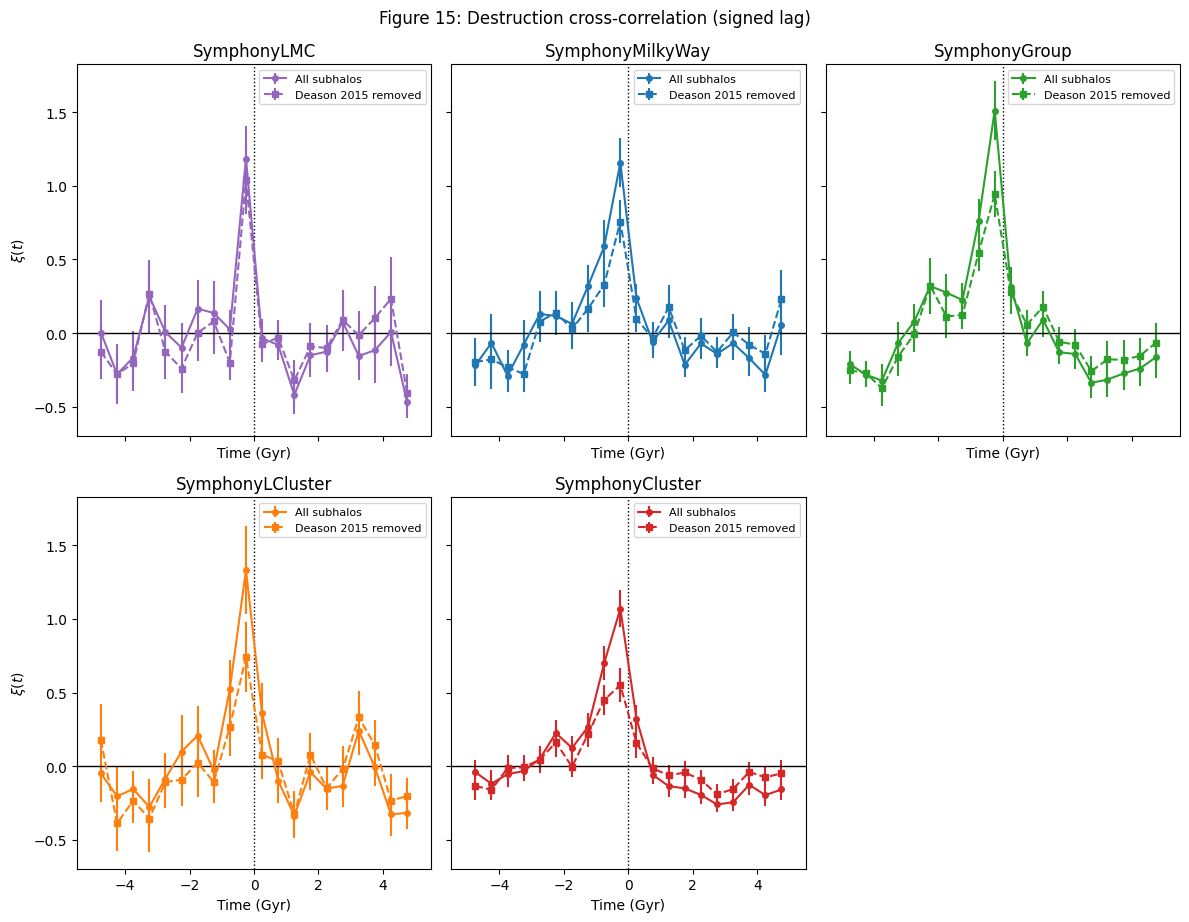

In [12]:
## PART 0: CONFIG
## Setup for all the physical/statistical choices throughout the pipeline:
## resolution-matched mass cutoff for the general subhalo population (Fig 1 + subhalos used in pairings in Fig 14)
## mass-ratio cutoff defining "massive progenitors"
## Deason et. al. (2015) spatio-temporal association window
## shared bin edges, so every suite/panel is directly comparable

## d'Souza & Bell use ELVIS, which is (somewhat) analogous to SymphonyMilkyWay
## They use a 10^9 Msun mass cutoff for their subhalos
## For consistent MASS RESOLUTION across suites of differing particle mass, this 10^9 Msun is converted to a PARTICLE COUNT using SymphonyMilkyWay
## and then that same particle count is used (converted through the particle mass of a given suite) to get the mass cutoff for that suite
## This is a "resolution-matched" analog of their analysis that should apply to all suites

ref_suite = "SymphonyMilkyWay"
ref_mass_msun = 1e9

ref_sim_dir = symlib.get_host_directory(base_dir, ref_suite, 0)
ref_params = symlib.simulation_parameters(ref_sim_dir)
ref_particle_mass_msun = ref_params["mp"] / ref_params["h100"]   ## convert from h^-1 Msun to physical Msun
n_particles_cut = ref_mass_msun/ref_particle_mass_msun

print(f"Reference suite: {ref_suite}")
print(f"Particle mass in reference suite = {ref_particle_mass_msun:.3e} Msun")
print(f"1e9 Msun = {n_particles_cut:.1f} particles is now the fixed particle count cutoff applied to every suite")
print()

## the Deason criterion referenced in d'Souza & Bell applies to subhalos that have been within the virial radius of a massive progenitor for
## "two consecutive timesteps" (in ELVIS), or a total CONTINUOUS time of 1 Gyr immediately prior to the subhalo's own infall into the main host
## Symphony's snapshot spacing is not necessarily the same as ELVIS, so instead the number of snapshots that span this 1 Gyr window is
## calculated per host and per subhalo rather than assuming a fixed window
deason_window_gyr = 1.0

## Massive progenitors are subhalos whose PEAK historical mass (Mpeak) is >= 10% of the main host's z = 0 virial mass (Mvir)
## This is computed directly per host (i.e against that host's z = 0 Mvir)
## Since the host's own mass grows significantly over time, an early-infalling major merger at some time can fail the 10% threshold criterion at z = 0,
## because the host mass generally only grows and subhalos generally get stripped and lose mass
## Worth keeping in mind...
## Mpeak / Mvir_host is already scale invariant, no conversions needed
progen_mass_ratio_cut = 0.1

## Fig 15's anchor point is this: "we find that referencing to a time when the massive progenitor first
## crosses a galacto-centric distance of 80 kpc maximises the cross-correlation signal for the
## destruction of subhaloes" -- NOT the massive progenitor's infall time (like in Fig. 14)
## Units: kpc, physical, matching h["x"], h["rvir"]'s existing units elsewhere in this pipeline.

## To generalize across suites the same way the mass cutoff is resolution-matched, instead the FRACTION of Rvir that 80 kpc represents
## in the reference suite (SymphonyMilkyWay) is fixed, then that same fraction, scaled by each HOST's own z=0 Rvir, becomes the crossing distance
## for every other host/suite.
mp_crossing_distance_kpc = 80.0
ref_h, ref_hist = symlib.read_subhalos(ref_sim_dir)
ref_scale_factors = symlib.scale_factors(ref_sim_dir)
ref_final_snap = len(ref_scale_factors) - 1
ref_host_rvir_z0 = ref_h["rvir"][0, ref_final_snap]
mp_crossing_frac_of_rvir = mp_crossing_distance_kpc / ref_host_rvir_z0

print(f"Reference host Rvir (z=0, {ref_suite} host 0) = {ref_host_rvir_z0:.1f} kpc")
print(f"{mp_crossing_distance_kpc:.0f} kpc = {mp_crossing_frac_of_rvir:.4f} x Rvir "
      f"-- this FRACTION is now applied to every host's own Rvir to get its equivalent '80 kpc' point")

## LAG MODE TOGGLE:
## "signed" keeps the sign of the difference (negative = infall before the massive progenitor, positive = infall after the massive progenitor)
## "absolute" folds both directions into one magnitude (more faithful to Fig 14)
## These toggles can be set independently for each figure (i.e if you want "signed" for Fig 14 but "absolute" for Fig 15)
fig14_lag_mode = "signed"     ## "signed" or "absolute"
fig15_lag_mode = "signed"     ## "signed" or "absolute"

## Bin edges appropriate to the lag mode:
## [0, max_lag] for "absolute", [-max_lag, max_lag] for "signed"
def make_bin_edges(lag_mode, max_lag = 5.0, step = 0.5):
    if lag_mode == "absolute":
        return np.arange(0.0, max_lag + step, step)
    elif lag_mode == "signed":
        return np.arange(-max_lag, max_lag + step, step)
    else:
        raise ValueError(f"Lag mode must be 'signed' or 'absolute', got {lag_mode!r}")

fig1_bin_edges = np.linspace(0.0, 14, 8)     ## 7 bins, 0 to 14 Gyr like Figure 1 --> unaffected by lag-mode toggle, Fig 1 isn't a time lag
fig14_bin_edges = make_bin_edges(fig14_lag_mode)
fig15_bin_edges = make_bin_edges(fig15_lag_mode)

oversample = 20                              ## random catalog size = oversample x N_subs per host
                                             ## reduces shot noise in DR(t)
RNG = np.random.default_rng(42)              ## random number generator with a seed for reproducible bootstrap draws/resampling

##############################################################################################################################

## PART 1: HELPERS (used inside the main dataloading loop and for the cross-correlation estimator)

## Returns the snapshot indices spanning the window_gyr period immediately preceding infall_snap (not including infall_snap itself)
## i.e "how far back do we need to look for this particular subhalo, given THIS host's own (possibly non-uniform) snapshot spacing
## Walks backward through THIS host's lookback_table until the elapsed time reaches window_gyr, or it runs out of earlier snapshots to check
## returns None if there isn't enough simulation history before infall_snap to span the window
def deason_window_snapshots(lookback_table, infall_snap, window_gyr = deason_window_gyr):

    infall_time = lookback_table[infall_snap]
    target_time = infall_time + window_gyr      ## further back = larger lookback time

    snap = infall_snap - 1
    if snap < 0:
        return None

    while snap > 0 and lookback_table[snap] < target_time:
        snap -= 1

    if lookback_table[snap] < target_time:
        return None                              ## ran out of history before spanning a full window

    return np.arange(snap, infall_snap)

## For each subhalo in sub_idx_pop, check whether it was CONTINUOUSLY within a massive progenitor's Rvir across the ~1 Gyr window
## immediately preceding ITS OWN infall into the main host
## A subhalo is tagged True as soon as it satisfies this criterion against ANY ONE of the massive progenitors in mp_sub_idx
## Subhalos do not need to be tested against multiple massive progenitors, since there is no meaningful difference between
## "associated with 1 massive progenitor" and "associated with 2+," at least for the purposes of Fig 14's tagging
## Returns a Boolean array of the same length/order as sub_idx_pop
def tag_deason_subhalos(h, lookback_table, mp_sub_idx, sub_idx_pop, sub_infall_snap_pop):

    deason_tag = np.zeros(len(sub_idx_pop), dtype = bool)

    for j in range(len(sub_idx_pop)):
        s_idx = sub_idx_pop[j]
        s_infall_snap = sub_infall_snap_pop[j]

        window_snaps = deason_window_snapshots(lookback_table, s_infall_snap)
        if window_snaps is None:
            continue              ## not enough simulation history before infall to test

        for k in range(len(mp_sub_idx)):
            mp_idx = mp_sub_idx[k]

            ## both the subhalo and the massive progenitor must actually exist at EVERY snapshot in the window
            ## if either drops out ("ok" = False) anywhere in the window, we can't evaluate their separation there, so skip this MP
            ok_window = h["ok"][s_idx, window_snaps] & h["ok"][mp_idx, window_snaps]
            if not np.all(ok_window):
                continue

            ## physical separation between the subhalo and the massive progenitor at every snapshot in the window,
            ## compared against the massive progenitor's Rvir at that snapshot (i.e "was the subhalo a subhalo of the massive progenitor")
            sep = np.linalg.norm(h["x"][s_idx, window_snaps] - h["x"][mp_idx, window_snaps], axis = 1)
            rvir_mp = h["rvir"][mp_idx, window_snaps]

            ## np.all is what makes this a "continuous" association test
            ## EVERY snapshot in the window must satisfy sep < rvir_mp
            if np.all(sep < rvir_mp):
                deason_tag[j] = True
                break                      ## subhalo tagged to at least one massive progenitor, no need to check others

    return deason_tag

## The snapshot at which a subhalo is destroyed/merges with the main progenitor branch --> D'Souza & Bell's t_disruption.
## Defined as the first snapshot AFTER the last snapshot the subhalo was tracked ("ok" = True)
## i.e. the snapshot immediately following its last real appearance in the catalog, Symlib's check for when it merged/was disrupted"
## Uses the LAST TRUE occurrence (rather than the first False after some earlier True),
## so a single transient "ok = False" blip (halo-finder noise) doesn't get mistaken for the actual destruction event,
## if the subhalo is re-detected at a later snapshot.
 
## Returns None if the subhalo is still tracked at final_snap
## (i.e. it's a SURVIVOR, not a destroyed subhalo, there's no destruction time to compute).
def find_destruction_snap(h, s_idx, final_snap):

    ## tracking "ok" for all valid subhalo indices s_idx
    ok_track = h["ok"][s_idx, :final_snap + 1]
    true_snaps = np.where(ok_track)[0]
    
    if len(true_snaps) == 0:
        return None                      ## never actually tracked (shouldn't happen given upstream selection)
        
    last_true = true_snaps[-1]
    
    if last_true == final_snap:
        return None                      ## still exists at z=0 --> this is a survivor, not destroyed
    
    return last_true + 1

## The first snapshot AT OR AFTER the massive progenitor's own infall at which its galactocentric distance from the host drops below crossing_kpc
## D'Souza & Bell's Fig. 15 anchor time ("first crosses a galacto-centric distance of 80 kpc").
 
## crossing_kpc is passed in explicitly since it is HOST-SPECIFIC: mp_crossing_frac_of_rvir x this host's own z=0 Rvir,
## so the crossing distance scales with the host's own dynamical scale
 
## Searches forward from mp_infall_snap (not from snap 0) since the massive progenitor must already be inside the host's virial radius before
## it can be meaningfully "crossing" some fraction of the host's Rvir -- this crossing generically happens some time AFTER infall.
 
## Returns None if the massive progenitor never gets that close before the simulation ends
## (e.g. destroyed while still far out, or still approaching at z=0).
def find_mp_crossing_snap(h, mp_idx, mp_infall_snap, final_snap, crossing_kpc):

    for snap in range(mp_infall_snap, final_snap + 1):
        
        if not h["ok"][mp_idx, snap]:
            continue
            
        r = np.linalg.norm(h["x"][mp_idx, snap])
        
        if r < crossing_kpc:
            return snap
            
    return None


## Pairwise (event_time - mp_time) lags for one halo's anchor time(s) against one population of event times
## --> (real data, for DD(t), or random-catalogue draws, for DR(t)).
## lag_mode = "signed": negative = event happened BEFORE the anchor time, positive = AFTER the anchor time.
## lag_mode = "absolute": turns both directions into a single magnitude |lag| (matches D'Souza & Bell's own Fig. 14/15 axes, which only run 0-5 Gyr).
## Returns every (event, anchor) 
def pair_lags(mp_times, event_times, mode = "signed"):
    
    if len(mp_times) == 0 or len(event_times) == 0:
        return np.array([])
 
    lag = (event_times[:, None] - mp_times[None, :]).ravel()
    return np.abs(lag) if mode == "absolute" else lag


## Computes the Davis & Peebles cross-correlation estimator xi(t) = (N_R/N_S)*(DD(t)/DR(t))-1
## DD(t) = count of (massive progenitor, associated subhalo) pairs whose infall time lag falls in bin t
## DR(t) = count of (massive progenitor, random subhalo) pairs whose infall time lag falls in bin t
## N_S = total number of subhalos actually paired (summed across all hosts in this suite)
## N_R = total number of random-catalog points actually paired (summed across all hosts in this suite)

## N_R/N_S prefactor corrects for the fact that N_R is deliberately made much larger than N_S to reduce shot noise in DR(t)
## Without it, DD/DR would be systematically suppressed simply because the random catalog has more points feeding it, nothing to do with real clustering

## PARAMETERS:
## host_data = list of per-host dicts with "mp_infall_time", "sub_infall_time", "deason_tag"
## all_sub_times = pooled empirical subhalo infall time distribution for THIS suite
##                (the random catalog is drawn from Fig 1 (without massive progenitors) via bootstrap resampling WITH REPLACEMENT)
## remove_deason = if True, subhalos with deason_tag = True are removed from the
##                 subhalo population before pairing (this produces the "Deason-removed curve")
## DD and DR pairs are pooled across every host in a suite prior to binning,
## then binned once at the end (rather than computing xi for each and averaging)
## This gives much better small-number statistics than a per-host calculation, since the median number of massive progenitors per host is only ~1.

## this function is used for both the surviving subhalos cross-correlation and the destroyed subhalos cross-correlation
def compute_xi(host_data, all_event_times, bin_edges, mp_key, event_key, deason_key = None,
               remove_deason = False, lag_mode = "signed", oversample = oversample, rng = RNG):
    
    dd_all, dr_all = [], []
    n_s_total = 0
    n_r_total = 0

    for hd in host_data:
        event_t = hd[event_key]
        
        if remove_deason:
            event_t = event_t[~hd[deason_key]]
        mp_t = hd[mp_key]

        n_s_total += len(event_t)
        dd_all.append(pair_lags(mp_t, event_t, mode = lag_mode))

        ## Random catalog: bootstrap draw (with replacement) from this suite's pooled, empirical subhalo infall-time distribution
        ## sized to "oversample" x this host's own (real) subhalo count, so DR(t) has much better statistics than DD(t) alone would
        n_draw = max(int(len(event_t) * oversample), 1)
        rand_t = rng.choice(all_event_times, size = n_draw, replace = True)
        n_r_total += len(rand_t)
        dr_all.append(pair_lags(mp_t, rand_t, mode = lag_mode))

    dd_lags = np.concatenate(dd_all) if dd_all else np.array([])
    dr_lags = np.concatenate(dr_all) if dr_all else np.array([])

    DD, _ = np.histogram(dd_lags, bins = bin_edges)
    DR, _ = np.histogram(dr_lags, bins = bin_edges)

    norm = n_r_total / n_s_total if n_s_total > 0 else np.nan

    ## bins where DR = 0 (no random pairs landed there) would otherwise raise a divide-by-zero error
    ## errstate suppresses the warning and lets xi come out as inf/nan in those bins, which is the correct behavior since
    ## the estimator is truly undefined there rather than crashing
    with np.errstate(divide = "ignore", invalid = "ignore"):
        xi = norm * (DD/DR) - 1.0

    centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    return centers, xi, DD, DR
    
## halo-level bootstrap error on xi(t):
## resample the hosts in this suite WITH REPLACEMENT n_boot times, recompute xi(t) each time (pooling DD/DR across the resampled set of hosts),
## and take the standard deviation across bootstrap realizations as the errorbar in each bin
## this captures halo-to-halo scatter (e.g some hosts having unusually many/few massive progenitors or subhalos) better than a naive Poisson-counting
## error on the pooled DD/DR pair counts would, since it doesn't assume all pairs are statistically independent draws
## (pairs from the same host share that host's particular accretion history)

## this is also generalized to work for both surviving and destroyed subhalos
def bootstrap_xi(host_data, all_event_times, bin_edges, mp_key, event_key, deason_key = None,
                  remove_deason = False, lag_mode = "signed", n_boot = 200, oversample = oversample):

    n_h = len(host_data)
    boot_xis = []
    centers = None

    for _ in range(n_boot):
        idx = RNG.integers(0, n_h, size = n_h)      ## resample host INDICES with replacement
        boot_data = [host_data[i] for i in idx]     ## build the resampled host list
        centers, xi, _, _ = compute_xi(boot_data, all_event_times, bin_edges, mp_key, event_key,
                                       deason_key = deason_key, remove_deason = remove_deason,
                                       lag_mode = lag_mode, oversample = oversample, rng = RNG)
        
        boot_xis.append(xi)

    boot_xis = np.array(boot_xis)

    return centers, np.nanstd(boot_xis, axis = 0)

#################################################################################################################################

## PART 2: MAIN LOOP
## for each suite, for each host, load data ONCE and build BOTH:
## a) the Fig 1 populations (All / Destroyed / Surviving / Surviving < Rvir)
## b) Fig 14 data structures (massive progenitor infall times, subhalo infall times, Deason association tag)
## Both are done in the same pass, since both figures need the same underlying per-host quantities (infall_times, masses, positions)

suite_fig1_results = {}
suite_fig14_hostdata = {}
suite_fig15_hostdata = {}

for suite_index, suite_name in enumerate(suite_list):

    ## Fig 1 accumulators --> flat lists across ALL hosts in this suite, converted to arrays after the loop finishes
    all_infall_times = []    
    destroyed_infall_times = []
    surviving_infall_times = []
    surviving_inside_rvir_infall_times = []

    ## Fig 14 and 15 accumulator: one dict per HOST (kept separate, unlike Fig 1)
    host_data_fig14 = []
    host_data_fig15 = []

    print(f"Loading suite {suite_name}...")

    ## particle mass and cosmology parameters are constant across a suite, so we can just use the first host to get these quantities
    sim_dir_0 = symlib.get_host_directory(base_dir, suite_name, 0)
    params = symlib.simulation_parameters(sim_dir_0)
    scale_factors = symlib.scale_factors(sim_dir_0)
    h100 = params["h100"]
    Om0 = params["Om0"]
    particle_mass_physical = params["mp"]/h100      ## convert from h^-1 Msun to physical Msun

    ## astropy cosmology object, used to convert every host's own snapshot scale factors into lookback times (Gyr) further down
    ## also constant across a suite, no need to compute multiple times
    cosmo = FlatLambdaCDM(H0 = h100 * 100, Om0 = Om0)

    ## this suite's mass cutoff --> same particle count as 1e9 Msun in SymphonyMilkyWay
    ## but converted using THIS suite's particle mass
    ## equal resolving power across suites, not equal absolute Msun
    mass_cut_suite = n_particles_cut * particle_mass_physical
    
    print(f"{suite_name}: particle mass = {particle_mass_physical:.3e} Msun, "
          f"cutoff = {n_particles_cut:.0f} particles = {mass_cut_suite:.3e} Msun "
          f"({'OK' if n_particles_cut >= 300 else 'BELOW 300-particle floor!'})")

    n_hosts = symlib.n_hosts(suite_name)

    ## diagnostics for the NEW Fig. 15 quantities specifically -- how often do we actually get
    ## a valid 80kpc-crossing time / destruction time, vs. how often is one unavailable
    n_mp_no_crossing = 0
    n_mp_with_crossing = 0
    
    for i_host in range(n_hosts):

        print(f"Starting on host {i_host+1}/{n_hosts}", end = "\r", flush = True)
        
        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        h, hist = symlib.read_subhalos(sim_dir)

        ## scale factors (and everything derived from it: lookback_table, final_snap, etc) must be read PER HOST, not reused from host 0
        ## this is because snapshot spacing can differ slightly between hosts in a given suite (e.g after restarting partway through), so
        ## reusing host 0's timing risks misaligned snapshots, final snaps, and lookback tables
        scale_factors = symlib.scale_factors(sim_dir)
        z = (1.0/scale_factors) - 1.0
        lookback_table = (cosmo.age(0) - cosmo.age(z)).value
        final_snap = len(scale_factors) - 1

        ## host's z = 0 virial mass
        host_mvir_z0 = h["mvir"][0, final_snap]

        ## remove host, get valid infall times
        sub_idx = np.arange(1, len(hist))       ## removing the host

        ## 2. select valid infall times
        infall_snap = hist["merger_snap"][sub_idx]  ## snapshot when subhalos first fell into the host's virial radius
        valid_infall = infall_snap >= 0             ## removing any -1's
        sub_idx = sub_idx[valid_infall]
        infall_snap = infall_snap[valid_infall]
        infall_time = lookback_table[infall_snap]   ## convert snapshot --> lookback time (Gyr)

        mpeak = hist["mpeak"][sub_idx]              ## each subhalo's PEAK mass (Msun)

        ## FIG 1:
        ## for Fig 1, resolution-matched mpeak cutoff only
        valid_mass = mpeak >= mass_cut_suite         ## mass cutoff described above
        sub_idx_fig1 = sub_idx[valid_mass]
        infall_time_fig1 = infall_time[valid_mass]

        ## "surviving" = still tracked (exists) at the z = 0 snapshot
        ## "destroyed" = merged/tidally disrupted by z = 0, no longer a tracked object
        ## h["ok"] is Symlib's existence flag, so the partition between "surviving" and "destroyed" is exact by construction
        surviving = h["ok"][sub_idx_fig1, final_snap]
        destroyed = ~surviving                           ## destroyed = not surviving

        ## of the surviving subhalos
        host_rvir_z0 = h["rvir"][0, final_snap]
        sub_pos_z0 = h["x"][sub_idx_fig1, final_snap]
        r_sub = np.linalg.norm(sub_pos_z0, axis = 1)
        inside_rvir = r_sub < host_rvir_z0
        surviving_inside_rvir = surviving & inside_rvir

        ## save populations
        all_infall_times.extend(infall_time_fig1)
        surviving_infall_times.extend(infall_time_fig1[surviving])
        destroyed_infall_times.extend(infall_time_fig1[destroyed])
        surviving_inside_rvir_infall_times.extend(infall_time_fig1[surviving_inside_rvir])

        ## FIG 14/15:
        
        ## Fig 14 massive progenitors and subhalo population (SAME resolution-matched cut as Fig 1) + Deason tagging'
        ## these variables are reused for Fig 15 as well
        is_subhalo = valid_mass                                        ## reusing Fig 1 mask
        is_mp = (mpeak / host_mvir_z0) >= progen_mass_ratio_cut        ## d'Souza & Bell's > 1:10 cut

        ## massive progenitors: their infall times (the "anchor" times for the cross-correlation)
        ## and their own catalog indices (needed below to look up position/Rvir history for Deason tagging of subhalos)
        mp_sub_idx = sub_idx[is_mp]
        mp_infall_time = infall_time[is_mp]
        mp_infall_snap = infall_snap[is_mp]

        ## subhalo population for the cross-correlation must EXCLUDE the massive progenitors, to avoid the trivial self-pairings
        ## these self-pairings would artificially spike DD(t) at t = 0
        sub_only_mask = is_subhalo & (~is_mp)
        sub_idx_pop = sub_idx[sub_only_mask]
        sub_infall_time_pop = infall_time[sub_only_mask]
        sub_infall_snap_pop = infall_snap[sub_only_mask]

        ## Deason et. al. (2015) tag: for each subhalo in the population above, was it CONTINUOUSLY within a massive progenitor's Rvir for the ~1Gyr
        ## immediately prior to its infall into the main host?
        ## this is a MASK, not a pairing rule --> doesn't affect "All Subhalos" curve at all, just removes subhalos to make the "Deason-removed" curve 
        deason_tag = tag_deason_subhalos(h, lookback_table, mp_sub_idx, sub_idx_pop, sub_infall_snap_pop)

        host_data_fig14.append({"mp_infall_time": mp_infall_time,
                                "sub_infall_time": sub_infall_time_pop,
                                "deason_tag": deason_tag})

        ## FIG 15 data:
        ## This host's own crossing distance: mp_crossing_frac_of_rvir x THIS host's z=0 Rvir
        host_crossing_kpc = mp_crossing_frac_of_rvir * host_rvir_z0

        ## Anchor: for each massive progenitor, the first snapshot >= its own infall at which
        ## it comes within host_crossing_kpc of the host -- NOT its infall time (that's Fig. 14's anchor).
        mp_crossing_time_list = []
        for k in range(len(mp_sub_idx)):
            crossing_snap = find_mp_crossing_snap(h, mp_sub_idx[k], mp_infall_snap[k], final_snap,
                                                    crossing_kpc = host_crossing_kpc)
            if crossing_snap is None:
                n_mp_no_crossing += 1
                continue
            n_mp_with_crossing += 1
            mp_crossing_time_list.append(lookback_table[crossing_snap])
        mp_crossing_time = np.array(mp_crossing_time_list)

        ## Event: destruction time of every DESTROYED subhalo in the general (MP-excluded) population
        ## survivors have no destruction time and are excluded here entirely
        ## (not just masked to False -- they simply don't belong to this population at all).
        destroyed_mask_pop = ~h["ok"][sub_idx_pop, final_snap]
        destroyed_idx_pop = sub_idx_pop[destroyed_mask_pop]
        destroyed_deason_tag = deason_tag[destroyed_mask_pop]   ## same tag, just restricted to the destroyed subset
 
        destruction_time_list = []
        keep_mask = np.zeros(len(destroyed_idx_pop), dtype=bool)
        for j in range(len(destroyed_idx_pop)):
            
            d_snap = find_destruction_snap(h, destroyed_idx_pop[j], final_snap)
            
            if d_snap is None:
                continue   ## shouldn't happen given destroyed_mask_pop, but defensive
            
            destruction_time_list.append(lookback_table[d_snap])
            keep_mask[j] = True
 
        destroyed_sub_time = np.array(destruction_time_list)
        destroyed_deason_tag = destroyed_deason_tag[keep_mask]

        host_data_fig15.append({"mp_crossing_time": mp_crossing_time,
                                "destroyed_sub_time": destroyed_sub_time,
                                "destroyed_deason_tag": destroyed_deason_tag})


    ## convert Fig 1 lists to arrays, store
    all_infall_times = np.asarray(all_infall_times)
    destroyed_infall_times = np.asarray(destroyed_infall_times)
    surviving_infall_times = np.asarray(surviving_infall_times)
    surviving_inside_rvir_infall_times = np.asarray(surviving_inside_rvir_infall_times)
    
    suite_fig1_results[suite_name] = {"all": all_infall_times,
                                      "destroyed": destroyed_infall_times,
                                      "surviving": surviving_infall_times,
                                      "surviving_inside_rvir": surviving_inside_rvir_infall_times}

    suite_fig14_hostdata[suite_name] = host_data_fig14
    suite_fig15_hostdata[suite_name] = host_data_fig15

    ## DIAGNOSTICS:
    print()
    n_mp_total = sum(len(hd["mp_infall_time"]) for hd in host_data_fig14)
    n_sub_total = sum(len(hd["sub_infall_time"]) for hd in host_data_fig14)
    n_tagged_total = sum(np.sum(hd["deason_tag"]) for hd in host_data_fig14)
    n_destroyed_total = sum(len(hd["destroyed_sub_time"]) for hd in host_data_fig15)
    print("Total:", len(all_infall_times))
    print("Destroyed:", len(destroyed_infall_times))
    print("Surviving:", len(surviving_infall_times))
    print("Surviving inside rvir:", len(surviving_inside_rvir_infall_times))
    print(f"Massive progenitors: {n_mp_total}, Subhaloes (MPs excluded): {n_sub_total}, "
          f"Deason-tagged: {n_tagged_total}")
    print(f"MPs with valid crossing time ({mp_crossing_frac_of_rvir:.4f} x host Rvir): "
          f"{n_mp_with_crossing}, without: {n_mp_no_crossing}")
    print(f"Destroyed subhaloes with valid destruction time (Fig 15 population): {n_destroyed_total}")
    print()

######################################################################################################################

## PART 3: Plotting Figure 1 for all suites

n_suites = len(suite_list)
ncols = 3
nrows = int(np.ceil(n_suites/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize = (12, 5 * nrows), sharex = True, sharey = True)
axes = np.atleast_1d(axes).flatten()

for i, suite_name in enumerate(suite_list):
    
    ax = axes[i]
    data = suite_fig1_results[suite_name]

    ## every histogram here uses the SAME fig1_bin_edges (defined once in part 0), so bars from different populations
    ## and different suite panels are all directly comparable
    ax.hist(data["all"], bins = fig1_bin_edges, color = "black", histtype = "step", lw = 1.5, label = "All", zorder = 10)
    ax.hist(data["destroyed"], bins = fig1_bin_edges, color = "tab:green", histtype = "step", linestyle = ":", lw = 1, label = "Destroyed")
    ax.hist(data["surviving"], bins = fig1_bin_edges, color = "tab:orange", histtype = "step", linestyle = "--", lw = 1, label = "Surviving")
    ax.hist(data["surviving_inside_rvir"], bins = fig1_bin_edges, color = "tab:purple", histtype = "step",
            linestyle = "--", lw = 1, label = "Surviving < Rv")
    
    ax.set_title(suite_name)

    # only leftmost column gets y-axis label
    if i % ncols == 0:
        ax.set_ylabel("Raw Counts")
    else:
        ax.yaxis.set_visible(False)
        
    ax.set_xlabel("Lookback time at infall [Gyr]")
    ax.legend(fontsize = 8)

## removing unused axes:
for j in range(n_suites, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
#plt.savefig("d'Souza & Bell Figure 1 in Symphony (raw counts 1e9 cutoff, density = True).png")
plt.show()

##########################################################################################################################################

## PART 4: Compute + plot Figure 14 for all suites

n_suites = len(suite_list)
ncols = 3
nrows = int(np.ceil(n_suites / ncols))

fig14, axes14 = plt.subplots(nrows, ncols, figsize=(12, 4.5 * nrows), sharex = True, sharey = True)
axes14 = np.atleast_1d(axes14).flatten()

for i, suite_name in enumerate(suite_list):
    
    ax = axes14[i]
    host_data = suite_fig14_hostdata[suite_name]

    ## the random catalog for THIS suite is drawn from THIS suite's own pooled subhalo infall time distribution
    ## i.e its own Fig 1 "All" population, minus the massive progenitors
    all_sub_times_suite = np.concatenate([hd["sub_infall_time"] for hd in host_data])

    ## Curve 1: "All subhalos" --> every massive progenitor/subhalo pair, no association filtering
    centers, xi_all, DD_all, DR_all = compute_xi(host_data, all_sub_times_suite, fig14_bin_edges,
                                                 mp_key = "mp_infall_time", event_key = "sub_infall_time",
                                                 deason_key = "deason_tag", remove_deason = False, lag_mode = fig14_lag_mode)

    ## Curve 2: "Deason-removed" --> same pairing prodcedure, but Deason-tagged subhalos are removed from the population first
    centers, xi_noD, DD_noD, DR_noD = compute_xi(host_data, all_sub_times_suite, fig14_bin_edges,
                                                 mp_key = "mp_infall_time", event_key = "sub_infall_time",
                                                 deason_key = "deason_tag", remove_deason = True, lag_mode = fig14_lag_mode)

    ## halo level bootstrap error bars for each curve
    _, xi_all_err = bootstrap_xi(host_data, all_sub_times_suite, fig14_bin_edges,
                                 mp_key = "mp_infall_time", event_key = "sub_infall_time", deason_key = "deason_tag",
                                 remove_deason = False, lag_mode = fig14_lag_mode)
    _, xi_noD_err = bootstrap_xi(host_data, all_sub_times_suite, fig14_bin_edges,
                                 mp_key = "mp_infall_time", event_key = "sub_infall_time", deason_key = "deason_tag",
                                 remove_deason = True, lag_mode = fig14_lag_mode)

    ax.errorbar(centers, xi_all, yerr = xi_all_err, marker = "o", ms = 4, color = colors[suite_name], label = "All subhalos")
    ax.errorbar(centers, xi_noD, yerr = xi_noD_err, marker = "s", ms = 4, color = colors[suite_name], linestyle = "--", label = "Deason 2015 removed")
    
    ax.axhline(0, color = "black", lw = 1)                    ## xi = 0 reference line --> no excess clustering above random chance

    if fig14_lag_mode == "signed":
        ax.axvline(0, color = "black", lw = 1, linestyle = ":")   ## vertical line at the massive progenitor infall time
        ax.set_xlim(-5.5, 5.5)
    else:
        ax.set_xlim(0, 5)
    
    ax.set_title(suite_name)

    if i % ncols == 0:
        ax.set_ylabel(r"$\xi(t)$")

    ax.set_xlabel("Time (Gyr)")
    ax.legend(fontsize = 8)

for j in range(n_suites, len(axes14)):
    fig14.delaxes(axes14[j])

plt.tight_layout()
fig.suptitle(f"Figure 14: Infall cross-correlation ({fig14_lag_mode} lag)", y = 1.02)
plt.show()

## PART 5: DESTRUCTION CROSS-CORRELATION
## same structure as Fig 14

n_suites = len(suite_list)
ncols = 3
nrows = int(np.ceil(n_suites / ncols))
 
fig15, axes15 = plt.subplots(nrows, ncols, figsize = (12, 4.5 * nrows), sharex = True, sharey = True)
axes15 = np.atleast_1d(axes15).flatten()

for i, suite_name in enumerate(suite_list):
    ax = axes15[i]
    host_data = suite_fig15_hostdata[suite_name]

    all_destruction_times_suite = np.concatenate([hd["destroyed_sub_time"] for hd in host_data])

    centers, xi_all, DD_all, DR_all = compute_xi(host_data, all_destruction_times_suite, fig15_bin_edges,
                                                 mp_key = "mp_crossing_time", event_key = "destroyed_sub_time",
                                                 deason_key = "destroyed_deason_tag", remove_deason = False, lag_mode = fig15_lag_mode)
    centers, xi_noD, DD_noD, DR_noD = compute_xi(host_data, all_destruction_times_suite, fig15_bin_edges,
                                                 mp_key = "mp_crossing_time", event_key = "destroyed_sub_time",
                                                 deason_key = "destroyed_deason_tag", remove_deason = True, lag_mode = fig15_lag_mode)

    _, xi_all_err = bootstrap_xi(host_data, all_destruction_times_suite, fig15_bin_edges,
                                 mp_key = "mp_crossing_time", event_key = "destroyed_sub_time", deason_key = "destroyed_deason_tag",
                                 remove_deason = False, lag_mode = fig15_lag_mode)
    _, xi_noD_err = bootstrap_xi(host_data, all_destruction_times_suite, fig15_bin_edges,
                                 mp_key = "mp_crossing_time", event_key = "destroyed_sub_time", deason_key = "destroyed_deason_tag",
                                 remove_deason = True, lag_mode = fig15_lag_mode)

    ax.errorbar(centers, xi_all, yerr = xi_all_err, marker = "o", ms = 4, color = colors[suite_name], label = "All subhalos")
    ax.errorbar(centers, xi_noD, yerr = xi_noD_err, marker = "s", ms = 4, color = colors[suite_name], linestyle = "--", label = "Deason 2015 removed")

    ax.axhline(0, color = "black", lw = 1)
    if fig15_lag_mode == "signed":
        ax.axvline(0, color = "black", lw = 1, linestyle = ":")
        ax.set_xlim(-5.5, 5.5)
    else:
        ax.set_xlim(0, 5)
 
    ax.set_title(suite_name)
    if i % ncols == 0:
        ax.set_ylabel(r"$\xi(t)$")
    ax.set_xlabel("Time (Gyr)")
    ax.legend(fontsize = 8)
 
for j in range(n_suites, len(axes15)):
    fig15.delaxes(axes15[j])
 
plt.tight_layout()
fig15.suptitle(f"Figure 15: Destruction cross-correlation ({fig15_lag_mode} lag)", y = 1.02)
fig15.savefig(f"C:/Users/steph/Symphony/figure15_destruction_{fig15_lag_mode}_lag.png", dpi = 200, bbox_inches = "tight")
plt.show()

<a id = "animations"></a>
## Subhalo Animations
[Back to Table of Contents](#table_of_contents)

The first animation qualitatively investigates the effect of these "massive progenitors" infalling onto the main host. Massive progenitors are (color), and their spatio-temporally associated subhalos (as determined via the Deason criterion) are (color). Unassociated subhalos are (color), and the main host is (color). Unlike in d'Souza & Bell, subhalos here are defined based on the typical 300 particles and "ok" survival criteria used elsewhere in this analysis.

The expectation given the previous results is that massive progenitor infalls "deplete" the surrounding region of subhalos by "focusing" associated and unassociated subhalos onto the main host, causing the massive spike in the $\xi(t)$ estimator plot. These would also seem to correlate with the times of "jumps" in the MAHs, and possibly also the time-dependent behavior of the concentration parameter, the rate of subhalo destruction over time (also as a correlation function), potentially the rate of mass loss of massive subhalos, and maybe some other properties (relaxation state?).

All animations only use the first halo in the suite, for now. In the future, I may broaden to somehow incorporate an "average" over all the hosts.

In [7]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from matplotlib.patches import Circle
from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle, Patch
from matplotlib.lines import Line2D

import os
import glob
from PIL import Image

In [28]:
## GOAL: create a visualization that shows the "depletion" of subhalos in the surroundings following a "massive progenitor" infalling into a host.

## CONFIG:
n_particles_cut = 300
massive_progenitor_frac = 0.1
min_assoc_time_gyr = 1.0

output_dir = "depletion"
image_glob = "depletion/*.png"
output_gif = "depletion.gif"
gif_frame_duration_ms = 100

## instantiating a PatchCollection of true-to-scale circles for a set of halos
def make_circle_collection(positions, radii, indices, snap, color, alpha):
    circles = [Circle((positions[i, snap, 0], positions[i, snap, 1]), radii[i, snap]) for i in indices]
    return PatchCollection(circles, facecolor = color, edgecolor = "none", alpha = alpha)

##########################################################################################################

## DATALOADING:

## read one host's halo catalog + merger tree history from Symlib
def load_simulation(base_dir, suite_name, host_num = 0):
    
    sim_dir = symlib.get_host_directory(base_dir, suite_name, host_num)

    print(sim_dir)
    
    h, hist = symlib.read_subhalos(sim_dir)
    params = symlib.simulation_parameters(sim_dir)
    scale_factors = symlib.scale_factors(sim_dir)

    return h, hist, params, scale_factors, sim_dir

## compute cosmic times from scale factors
## snapshot-indexed lookup table of cosmic time (Gyr) and redshift
def compute_cosmic_times(scale_factors, params):

    h100 = params["h100"]
    Om0 = params["Om0"]
    cosmo = FlatLambdaCDM(H0 = h100 * 100, Om0 = Om0)
    z = (1.0 / scale_factors) - 1.0
    cosmic_times = cosmo.age(z).value

    return cosmic_times, z

## convert to physical Msun
def conv_particle_mass(params):
    return params["mp"] / params["h100"]

######################################################################################################################

## HALO/SUBHALO SELECTION:

## split the combined (host + subhalo) catalog into host and subhalo pieces
def get_host_and_subhalo_arrays(h, hist):
    return {"host_pos": h["x"][0, :],
            "host_rvir": h["rvir"][0, :],
            "host_mvir": h["mvir"][0, :],
            "sub_pos": h["x"][1:, :],
            "sub_rvir": h["rvir"][1:, :],
            "sub_mvir": h["mvir"][1:, :],
            "sub_ok": h["ok"][1:, :],
            "sub_mpeak": hist["mpeak"][1:],
            "sub_infall_snap": hist["merger_snap"][1:]}

## performing the 300 particles and ok cut
def compute_valid_mask(sub_mvir, sub_ok, mp_mass):
    return (sub_mvir >= mp_mass) & sub_ok

## Boolean mask (over subhalo index) of massive progenitors
def identify_massive_progenitors(sub_mpeak, host_mvir_z0, valid_mask, frac = massive_progenitor_frac):
    ever_valid = valid_mask.any(axis = 1)
    return (sub_mpeak >= frac * host_mvir_z0) & ever_valid

## DEASON ASSOCIATION CRITERION:

## Boolean mask (length = nsub) of subhalos
## associated = subhalo was *continuously* within the massive progenitor's Rvir for the last ≥1 Gyr before the subhalo's infall into the host.
def find_associated_subhalos(mp_i, sub_pos, sub_rvir, sub_ok, valid_mask, sub_infall_snap, dt, snap_idx, min_time_gyr = min_assoc_time_gyr):

    nsub = sub_pos.shape[0]
    mp_infall_snap = sub_infall_snap[mp_i]

    if mp_infall_snap < 0:
        return np.zeros(nsub, dtype = bool)

    mp_pos = sub_pos[mp_i]
    mp_rvir = sub_rvir[mp_i]
    mp_ok = sub_ok[mp_i]

    sep = np.linalg.norm(sub_pos - mp_pos[None, :, :], axis = 2)
    within_rvir = sep < mp_rvir[None, :]
    qualifying = within_rvir & valid_mask & mp_ok[None, :]

    associated = np.zeros(nsub, dtype = bool)

    ## step backwards through infall times, looking for when the subhalo was last outside the massive progenitor's Rvir
    for i in range(nsub):
        infall_s = sub_infall_snap[i]
        if infall_s <= 0:
            continue
        t = 0.0
        for s in range(infall_s - 1, -1, -1):
            if qualifying[i, s]:
                t += dt[s]
            else:
                break   # streak broken -- stop counting
        associated[i] = t >= min_time_gyr

    associated[mp_i] = False      ## not associated with itself

    return associated

def compute_all_associations(mp_idx, sub_pos, sub_rvir, sub_ok, valid_mask, sub_infall_snap, dt, snap_idx):

    associated_masks = {mp_i: find_associated_subhalos(mp_i, sub_pos, sub_rvir, sub_ok, valid_mask, sub_infall_snap, dt, snap_idx) for mp_i in mp_idx}

    nsub = sub_pos.shape[0]
    associated_any = np.zeros(nsub, dtype = bool)

    for mask in associated_masks.values():
        associated_any |= mask

    return associated_masks, associated_any

################################################################################################################################

## PLOTTING:

## returns Boolean masks (other / associated / massive progenitor)
def classify_subhalos_at_snapshot(snap, valid_mask, massive_progenitors, associated_any):

    exists = valid_mask[:, snap]
    
    is_mp = massive_progenitors & exists
    is_assoc = associated_any & exists & ~massive_progenitors
    is_other = exists & ~massive_progenitors & ~associated_any

    return is_other, is_assoc, is_mp

def plot_snapshot(ax, snap, sub_pos, sub_rvir, host_rvir, cosmic_times, z, plot_lim, valid_mask, massive_progenitors, associated_any):

    ax.clear()

    host_circle = plt.Circle((0, 0), host_rvir[snap], color = "black", fill = False, lw = 1.5)

    ax.add_patch(host_circle)

    is_other, is_assoc, is_mp = classify_subhalos_at_snapshot(snap, valid_mask, massive_progenitors, associated_any)

    other_idx = np.where(is_other)[0]
    assoc_idx = np.where(is_assoc)[0]
    mp_idx_snap = np.where(is_mp)[0]

    if len(other_idx):
        ax.add_collection(make_circle_collection(sub_pos, sub_rvir, other_idx, snap, color = "tab:blue", alpha = 0.4))

    if len(assoc_idx):
        ax.add_collection(make_circle_collection(sub_pos, sub_rvir, assoc_idx, snap, color = "tab:red", alpha = 0.5))

    if len(mp_idx_snap):
        ax.add_collection(make_circle_collection(sub_pos, sub_rvir, mp_idx_snap, snap, color = "tab:purple", alpha = 0.6))


    ax.set_xlim(-plot_lim, plot_lim)
    ax.set_ylim(-plot_lim, plot_lim)
    ax.set_aspect("equal")
    ax.set_xlabel("x [kpc]")
    ax.set_ylabel("y [kpc]")
    ax.set_title(f"t = {cosmic_times[snap]:.2f} Gyr  (z = {z[snap]:.2f})")

    legend_elements = [Patch(facecolor = "tab:blue", alpha = 0.4, label = "Unassociated subhalos"),
                       Patch(facecolor = "tab:red", alpha = 0.5, label = "Associated subhalos"),
                       Patch(facecolor = "tab:purple", alpha = 0.6, label = "Massive Progenitor(s)"),
                       Line2D([0], [0], color = "black", lw = 1.5, label = "Host virial radius")]
        
    ax.legend(handles = legend_elements, loc = "upper right", fontsize = 7)

## Loop over snapshots, saving one PNG per frame
def render_all_snapshots(snapshots, output_dir, ax, sub_pos, sub_rvir, host_rvir, cosmic_times, z,
                         valid_mask, massive_progenitors, associated_any, sim_dir):

    os.makedirs(output_dir, exist_ok = True)
    plot_lim = 2 * np.nanmax(host_rvir)

    halo_name = os.path.basename(sim_dir)
    suite_name = os.path.basename(os.path.dirname(sim_dir))
    ax.figure.suptitle(f"{suite_name} — {halo_name}", fontsize = 10)

    for snap in snapshots:
        plot_snapshot(ax, snap, sub_pos, sub_rvir, host_rvir, cosmic_times, z, plot_lim, valid_mask, massive_progenitors, associated_any)
        ax.figure.savefig(f"{output_dir}/snap_{snap:03d}.png", dpi = 200)


## Assemble saved PNGs (sorted by filename) into a looping GIF image
def build_gif(image_glob, output_gif_path, duration_ms = gif_frame_duration_ms):
    png_files = sorted(glob.glob(image_glob))
    if not png_files:
        raise FileNotFoundError(f"No PNGs found matching {image_glob!r}")
 
    frames = [Image.open(f) for f in png_files]
    frames[0].save(output_gif_path, save_all = True, append_images = frames[1:],
                    duration = duration_ms, loop = 0)


#########################################################################################################################################


## MAIN/ENTRYPOINT:

def main(base_dir, suite_list, host_num = 0):

    suite_name = suite_list[0]

    print(suite_name)

    h, hist, params, scale_factors, sim_dir = load_simulation(base_dir, suite_name, host_num)
    snapshots = np.arange(len(scale_factors))
    snap_idx = snapshots

    cosmic_times, z = compute_cosmic_times(scale_factors, params)
    dt = np.gradient(cosmic_times)
    mp_mass = n_particles_cut * conv_particle_mass(params)

    arrs = get_host_and_subhalo_arrays(h, hist)

    valid_mask = compute_valid_mask(arrs["sub_mvir"], arrs["sub_ok"], mp_mass)
    host_mvir_z0 = arrs["host_mvir"][-1]

    massive_progenitors = identify_massive_progenitors(arrs["sub_mpeak"], host_mvir_z0, valid_mask)
    mp_idx = np.where(massive_progenitors)[0]

    associated_masks, associated_any = compute_all_associations(mp_idx, arrs["sub_pos"], arrs["sub_rvir"], arrs["sub_ok"], valid_mask,
                                                                arrs["sub_infall_snap"], dt, snap_idx)

    fig, ax = plt.subplots(figsize = (6, 6))
    render_all_snapshots(snapshots, output_dir, ax, arrs["sub_pos"], arrs["sub_rvir"], arrs["host_rvir"],
                         cosmic_times, z, valid_mask, massive_progenitors, associated_any, sim_dir)

    plt.close(fig)

    build_gif(image_glob, output_gif)

    print(f"Saved animation to {output_gif}")

    return associated_masks, associated_any


if __name__ == "__main__":
    base_dir = base_dir
    suite_list = ["SymphonyCluster"]
    main(base_dir, suite_list)

SymphonyCluster
C:/Users/steph/Symphony\SymphonyCluster\Halo156
Saved animation to depletion.gif


1 200
2 200
3 200
4 200
5 200
6 200
7 200
8 200
9 200
10 200
11 200
12 200
13 200
14 200
15 200
16 200
17 200
18 200
19 200
20 200
21 200
22 200
23 200
24 200
25 200
26 200
27 200
28 200
29 200
30 200
31 200
32 200
33 200
34 200
35 200
36 200
37 200
38 200
39 200
40 200
41 200
42 200
43 200
44 200
45 200
46 200
47 200
48 200
49 200
50 200
51 200
52 200
53 200
54 200
55 200
56 200
57 200
58 200
59 200
60 200
61 200
62 200
63 200
64 200
65 200
66 200
67 200
68 200
69 200
70 200
71 200
72 200
73 200
74 200
75 200
76 200
77 200
78 200
79 200
80 200
81 200
82 200
83 200
84 200
85 200
86 200
87 200
88 200
89 200
90 200
91 200
92 200
93 200
94 200
95 200
96 200
97 200
98 200
99 200
100 200
101 200
102 200
103 200
104 200
105 200
106 200
107 200
108 200
109 200
110 200
111 200
112 200
113 200
114 200
115 200
116 200
117 200
118 200
119 200
120 200
121 200
122 200
123 200
124 200
125 200
126 200
127 200
128 200
129 200
130 200
131 200
132 200
133 200
134 200
135 200
136 200
137 200
138 200
139 

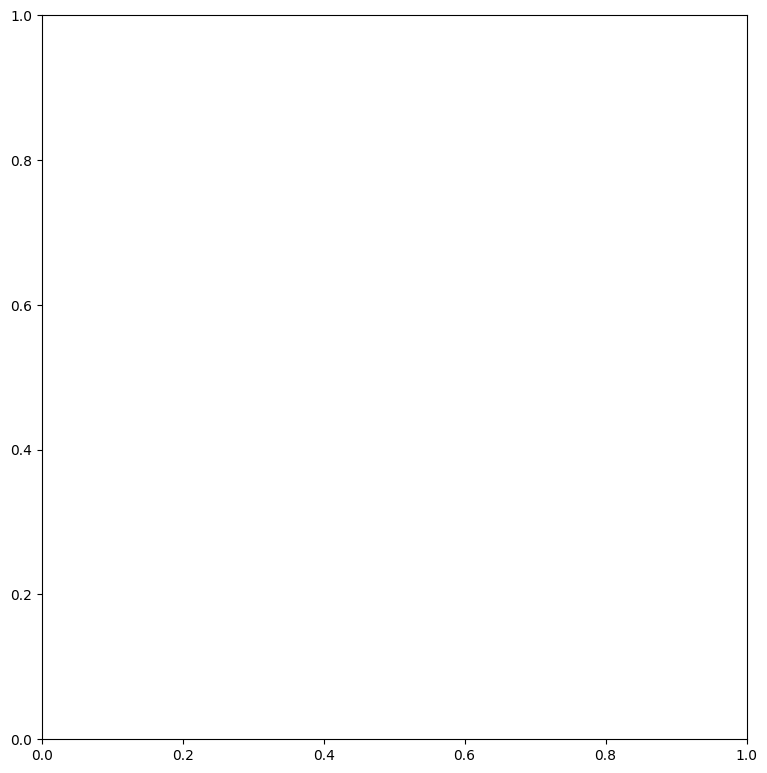

In [3]:
# generating subhalo location and mass vs time gifs!

from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

base_dir = "C:/Users/steph/Symphony"
suite_list = ["SymphonyCluster"]
image_directory = "subhalo_gif/*.png"
output_gif_path = "subhalo_animation.gif"

fig, ax = plt.subplots(ncols = 1, nrows = 1, figsize = (8, 8))

for suite_index, suite_name in enumerate(suite_list):
    n_hosts = symlib.n_hosts(suite_name)
    
    for i_host in range(1):
        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        scale_factors = symlib.scale_factors(sim_dir)
        h, hist = symlib.read_subhalos(sim_dir)

        for snap_index, snap in enumerate(scale_factors):
            host = h[0, snap_index]
            symlib.plot_circle(ax, host["x"][0], host["x"][1], host["rvir"], c = "tab:red")
            
            z0_radius = 100
        
            for i in range(1, len(h)):
                sub = h[i, snap_index]
                if sub["ok"]:
                    symlib.plot_circle(ax, sub['x'][0], sub['x'][1], sub['rvir'], c = "tab:blue", lw = 1.5)

            ax.set_xlim(-7*host["rvir"], 7*host["rvir"])
            ax.set_ylim(-7*host["rvir"], 7*host["rvir"])                            
            #ax.set_xlim(-3000, 3000)
            #ax.set_ylim(-3000, 3000)
            
            ax.set_title(f'a = {(snap):2f}')
            plt.tight_layout()
            
            output_directory = "subhalo_gif"
            filename = f"subhalo_image_{snap_index}.png"
            
            if not os.path.exists(output_directory):
                os.makedirs(output_directory)
                
            full_path = os.path.join(output_directory, filename)
            plt.savefig(full_path, dpi = 100, facecolor = 'white')

            if snap_index < len(scale_factors):
                print(snap_index + 1, len(scale_factors))
                ax.clear()

In [4]:
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

image_directory = "subhalo_gif/*.png"
output_gif_path = "subhalo_animation.gif"

image_paths = glob.glob(image_directory)
image_paths = sorted(glob.glob(image_directory), key=lambda x: int(re.search(r"(\d+)", x).group()))
 
# Load images 
images = []
for path in image_paths:
    img = Image.open(path)
    images.append(img)

if images:
    images[0].save(output_gif_path, save_all=True, append_images=images[1:], duration = 75, loop=0)
    print(f"GIF created and saved at {output_gif_path}")
else:
    print("No images found in the specified directory.")

GIF created and saved at subhalo_animation.gif
